In [1]:
import numpy as np
import random
from multiprocessing import Pool
import pandas as pd
from scipy.interpolate import interp1d
from scipy.special import gamma, erf
import scipy.stats as stats
from scipy.stats import binom

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
font_manager.fontManager.addfont('/home/vvelan/DarkLim/examples/styles/Times_New_Roman.ttf')

mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.style.use('/home/vvelan/DarkLim/examples/styles/Style.mplstyle')

import sys
sys.path.insert(0, 'ExistingLimits/')
#import MichaelLimits as ML

import darklim
sys.path.insert(0, '/home/vvelan/DarkELF/')
import darkelf

import qetpy
import detprocess
import h5py
import time
import pickle
import glob

%matplotlib inline


In [2]:
def run57_lee_bkgd(scale_by=1.0):
    fin = 'Run57_LEE_templates/combined_spectra_shared57_CRESST_extrap.txt'
    template = np.loadtxt(fin,skiprows=1)
    interp_func = interp1d(template[:,0],template[:,1],
                            bounds_error=False,
                            #fill_value='extrapolate',
                            fill_value=0.,
                            assume_sorted=True)

    return lambda x: (interp_func(x) / 86400. * scale_by)


# NR Requirement

In [3]:
### Load template
template = detprocess.Template(verbose=True)
template.load_hdf5('/home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5')

# Load shared 2x1 template to get the energy scale right, but we only use the left channel template shape and PSD
channel = 'Mv3025pcBigFinsLeft|Mv3025pcBigFinsRight'

templates_td, t_sec_template, metadata = template.get_template(channel, return_metadata=True, tag='shared')
templates_td = np.reshape(templates_td[0,0], (1,1,templates_td.shape[-1]))
_, _, f_frequencies = templates_td.shape
fs = metadata['sample_rate']
pretrig = metadata['nb_pretrigger_samples']

csd, freqs_csd, _ = template.get_csd(channel, fold=False, return_metadata=True, tag='default')
csd = np.reshape(csd[0,0], (1,1,csd.shape[-1]))


### Convert to multichannel format

# Rescale template so that the energy resolution per channel is some assumed value
base_energy_resolution = 0.3977  # eV; this is the resolution of the 1x1 shared template from Run 57
GaAs_energy_resolution = 0.617
PD_energy_resolution = 0.163
n_sigma = 4.0  # Number of sigma for the trigger

E_th_GaAs = n_sigma * GaAs_energy_resolution
E_th_PD = n_sigma * PD_energy_resolution

E_exposure_GaAs = E_th_GaAs # The energy cutoff to calculate effective exposure. Can be the threshold or some other value.
E_exposure_PD = E_th_PD 

template_OF = np.zeros((3, 3, f_frequencies))
template_OF[0, 0, :] = np.copy(templates_td)
template_OF[1, 1, :] = np.copy(templates_td) 
template_OF[2, 2, :] = np.copy(templates_td)

csd_OF = np.zeros((3, 3, f_frequencies))
csd_OF[0, 0, :] = np.copy(csd) * (GaAs_energy_resolution / base_energy_resolution)**2
csd_OF[1, 1, :] = np.copy(csd) * (PD_energy_resolution / base_energy_resolution)**2
csd_OF[2, 2, :] = np.copy(csd) * (PD_energy_resolution / base_energy_resolution)**2


INFO: Loading filter data from file /home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5


In [4]:
### Load the simulation parameters
run_length_hours = 6
dirname = 'required_performance_NR_like/'

E_max_PD_keV = 35e-3
E_max_GaAs_keV = 1000e-3

LEE_improvement_PD = 1. # Per-volume improvement factor for the PD
LEE_volume_scale_PD = 0.32 # Ratio of PD volume to Run 57 Si volume

LEE_improvement_GaAs = 1. # Per-volume improvement factor for the GaAs
LEE_volume_scale_GaAs = 3.84 # Ratio of GaAs volume to Run 57 Si volume

# We probably don't change these
sim_trace_length = 1_250_000 * 10
sim_trace_length_s = sim_trace_length / fs  # Convert to seconds
n_simulations_per_run = int(np.floor(run_length_hours * 3600 / sim_trace_length_s))
n_traces_per_sim = int(sim_trace_length / f_frequencies)


In [ ]:
### Load the simulation results

E0_full = []
E1_full = []
E2_full = []
sim_number_full = []
trigger_time_full = []
delta_delta_full = []
detected_full = []

n_runs = 0
for run_id in range(50):
    fns = glob.glob(dirname + f'my_simulation_3fold_{run_id:02d}*.pkl')
    if len(fns) == 0:
        continue
    with open(fns[0], 'rb') as f:
        results = pickle.load(f)
        
        E0_full += [e for result in results for e in result[0]]
        E1_full += [e for result in results for e in result[1]]
        E2_full += [e for result in results for e in result[2]]
        sim_number_full += [e for result in results for e in result[3]]
        trigger_time_full += [e for result in results for e in result[4]]
        delta_delta_full += [e for result in results for e in result[5]]
        detected_full += [e for result in results for e in result[6]]
        
        n_runs += 1
        del results
    print(run_id)

print(f'Loaded {n_runs} runs of simulation results.')

E0_full = np.array(E0_full)
E1_full = np.array(E1_full)
E2_full = np.array(E2_full)
sim_number_full = np.array(sim_number_full)
trigger_time_full = np.array(trigger_time_full)
delta_delta_full = np.array(delta_delta_full)
detected_full = np.array(detected_full)


0
1


In [ ]:
### Calculate the effective exposure in the GaAs and PD detectors, based on the observed triggers

# Exposure in a single PD detector
n_triggers_obs_PD1 = sum(E1_full > E_exposure_PD)
print(f'\nNumber of triggers observed in PD 1: {n_triggers_obs_PD1}')

E_above_th_PD1 = np.geomspace(E_exposure_PD * 1e-3, E_max_PD_keV, 250)
dRdE_above_th_PD1 = run57_lee_bkgd(scale_by=LEE_improvement_PD)(E_above_th_PD1)
R_above_th_PD1 = np.trapz(dRdE_above_th_PD1, E_above_th_PD1)
print(f'Expected rate of triggers in PD 1 above threshold: {R_above_th_PD1:.2e} Hz')

eff_exposure_PD1_hours = n_triggers_obs_PD1 / R_above_th_PD1 / 3600
print(f'Effective exposure in PD: {eff_exposure_PD1_hours:.2f} hours (no volume scaling or LEE improvement)')

# Exposure in the GaAs detector
n_triggers_obs_GaAs = sum(E0_full > E_exposure_GaAs)
print(f'\nNumber of triggers observed in GaAs: {n_triggers_obs_GaAs}')

E_above_th_GaAs = np.geomspace(E_exposure_GaAs * 1e-3, E_max_GaAs_keV, 250)
dRdE_above_th_GaAs = run57_lee_bkgd(scale_by=LEE_improvement_PD)(E_above_th_GaAs)
R_above_th_GaAs = np.trapz(dRdE_above_th_GaAs, E_above_th_GaAs)
print(f'Expected rate of triggers in GaAs above threshold: {R_above_th_GaAs:.2e} Hz')

eff_exposure_GaAs_hours = n_triggers_obs_GaAs / R_above_th_GaAs / 3600
print(f'Effective exposure in GaAs: {eff_exposure_GaAs_hours / 24:.2f} days (no volume scaling or LEE improvement)')

# Apply the LEE and volume scaling
print('\n##########################\n')
eff_exposure_PD1_hours /= LEE_volume_scale_PD
eff_exposure_per_run_PD1_hours = eff_exposure_PD1_hours / n_runs
eff_exposure_GaAs_hours /= LEE_volume_scale_GaAs
eff_exposure_per_run_GaAs_hours = eff_exposure_GaAs_hours / n_runs
print(f'Effective exposure in PD after LEE and volume scaling: {eff_exposure_PD1_hours:.2f} hours ({eff_exposure_per_run_PD1_hours:.2f} hours per run)')
print(f'Effective exposure in GaAs after LEE and volume scaling: {eff_exposure_GaAs_hours:.2f} hours ({eff_exposure_per_run_GaAs_hours:.2f} hours per run)')


Number of triggers observed in PD 1: 99722395
Expected rate of triggers in PD 1 above threshold: 1.05e+02 Hz
Effective exposure in PD: 264.39 hours (no volume scaling or LEE improvement)

Number of triggers observed in GaAs: 3144149
Expected rate of triggers in GaAs above threshold: 6.19e-02 Hz
Effective exposure in GaAs: 587.72 days (no volume scaling or LEE improvement)

##########################

Effective exposure in PD after LEE and volume scaling: 826.22 hours (16.52 hours per run)
Effective exposure in GaAs after LEE and volume scaling: 3673.28 hours (73.47 hours per run)


Effective 1-fold exposure in GaAs: 153.05 days
Effective 1-fold exposure in PD 1: 34.43 days
Effective 2-fold exposure: 421.52 days
Effective 3-fold exposure: 1160.89 days

Rates [1/day]:
1-fold in GaAs: 20542
1-fold in PD 1: 2896729
2-fold in GaAs, with either PD: 2.67e+02
3-fold in GaAs: 4.16e-01
3-fold in GaAs with Delta Chi2 < 9: 2.80e-01

Raw Numbers:
Number of detected events: 209,967,756
Number of events passing the 2-fold cut: 112,604
Number of events passing all cuts: 325


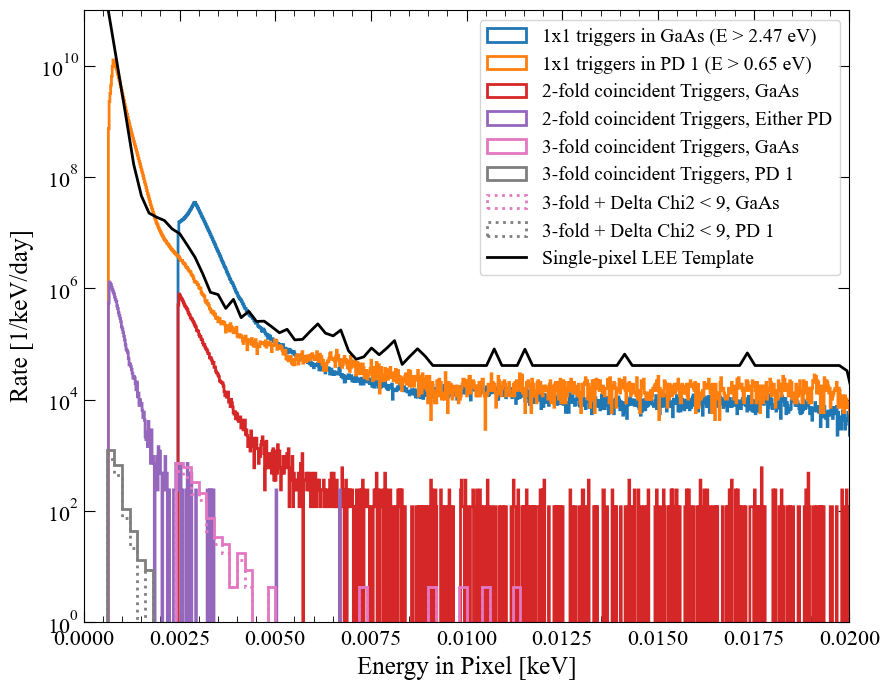

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(9, 7))
keV_bins = np.arange(0.1, 100, 0.02) * 1e-3


####################
# 1-fold coincidence
####################

single_pixel = E0_full > E_th_GaAs
duration_days = eff_exposure_GaAs_hours / 24
ax.hist(E0_full[single_pixel]*1e-3, bins=keV_bins,
        weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C0', lw=2,
        label=f'1x1 triggers in GaAs (E > {E_th_GaAs:.2f} eV)')
hist_E_E0_single, bin_edges = np.histogram(E0_full[single_pixel]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days))
R_single_GaAs = sum(hist_E_E0_single * np.diff(bin_edges))
print(f'Effective 1-fold exposure in GaAs: {duration_days:.2f} days')

single_pixel = E1_full > E_th_PD
duration_days = eff_exposure_PD1_hours / 24
ax.hist(E1_full[single_pixel]*1e-3, bins=keV_bins,
        weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C1', lw=2,
        label=f'1x1 triggers in PD 1 (E > {E_th_PD:.2f} eV)')
hist_E_E1_single, bin_edges = np.histogram(E1_full[single_pixel]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days))
R_single_PD_A = sum(hist_E_E1_single * np.diff(bin_edges))
print(f'Effective 1-fold exposure in PD 1: {duration_days:.2f} days')

# ####################
# # 2-fold coincidence
# ####################

detected = (E0_full > E_th_GaAs) * (E1_full > E_th_PD) + (E0_full > E_th_GaAs) * (E2_full > E_th_PD)
detected_A = (E0_full > E_th_GaAs) * (E1_full > E_th_PD)
detected_2fold = np.copy(detected)

duration_days = eff_exposure_per_run_GaAs_hours * eff_exposure_per_run_PD1_hours / run_length_hours / 24 * n_runs
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C3', lw=2,
        label='2-fold coincident Triggers, GaAs')
ax.hist(E1_full[detected_A]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected_A), 2/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C4', lw=2,
        label='2-fold coincident Triggers, Either PD')

hist_E_2fold_PD, bin_edges = np.histogram(E1_full[detected_A]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected_A), 2/np.diff(keV_bins)[0]/duration_days))
hist_E_2fold_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_2fold = sum(hist_E_2fold_GaAs * np.diff(bin_edges))

print(f'Effective 2-fold exposure: {duration_days:.2f} days')

# Export to a file
E_save = 0.5 * (keV_bins[1:] + keV_bins[:-1])
np.savetxt(dirname + 'background_spectrum_2fold.txt',
           np.column_stack((E_save, hist_E_2fold_GaAs)),
           header='Energy [keV]     dRdE GaAs [1/keV/day]',
           fmt='%.4e')


# ####################
# # 3-fold coincidence
# ####################

keV_bins = np.arange(0, 40, 0.2) * 1e-3  # Reduce the number of bins for 3-fold coincidence histogram
detected = (E0_full > E_th_GaAs) * (E1_full > E_th_PD) * (E2_full > E_th_PD)
duration_days = eff_exposure_per_run_GaAs_hours * eff_exposure_per_run_PD1_hours**2 / run_length_hours**2 / 24 * n_runs
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C6', lw=2,
        label='3-fold coincident Triggers, GaAs')
ax.hist(E1_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C7', lw=2,
        label='3-fold coincident Triggers, PD 1')

hist_E_3fold_PD, bin_edges = np.histogram(E1_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
hist_E_3fold_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_3fold = sum(hist_E_3fold_GaAs * np.diff(bin_edges))

print(f'Effective 3-fold exposure: {duration_days:.2f} days')

# ####################
# # Adding delta delta cut
# ####################

detected = (E0_full > E_th_GaAs) * (E1_full > E_th_PD) * (E2_full > E_th_PD) * (delta_delta_full < 9)
detected_overall = np.copy(detected)
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C6', lw=2, linestyle=':',
        label='3-fold + Delta Chi2 < 9, GaAs')
ax.hist(E1_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C7', lw=2, linestyle=':',
        label='3-fold + Delta Chi2 < 9, PD 1')

hist_E_3fold_delta_PD, bin_edges = np.histogram(E1_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
hist_E_3fold_delta_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_3fold_delta = sum(hist_E_3fold_delta_GaAs * np.diff(bin_edges))

# Export to a file
E_save = 0.5 * (keV_bins[1:] + keV_bins[:-1])
np.savetxt(dirname + 'background_spectrum_3fold.txt',
           np.column_stack((E_save, hist_E_3fold_delta_GaAs)),
           header='Energy [keV]     dRdE GaAs [1/keV/day]',
           fmt='%.4e')

# ####################
# # Wrapping up
# ####################


E_arr = np.linspace(0.1, 50, 250) * 1e-3
dRdE_arr = run57_lee_bkgd(scale_by=LEE_improvement_GaAs)(E_arr) * 86400
ax.plot(E_arr, dRdE_arr, color='k', label='Single-pixel LEE Template', lw=2)

ax.set_yscale('log')
ax.set_xlabel('Energy in Pixel [keV]')
ax.set_ylabel('Rate [1/keV/day]')
ax.set_ylim([1e0, 1e11])
ax.set_xlim([0, 20e-3])

ax.legend(loc='best', fontsize=14)
fig.tight_layout()
fig.show()

print(f'\nRates [1/day]:')
print(f'1-fold in GaAs: {R_single_GaAs:.0f}')
print(f'1-fold in PD 1: {R_single_PD_A:.0f}')
print(f'2-fold in GaAs, with either PD: {R_coincident_2fold:.2e}')
print(f'3-fold in GaAs: {R_coincident_3fold:.2e}')
print(f'3-fold in GaAs with Delta Chi2 < 9: {R_coincident_3fold_delta:.2e}')

print('\nRaw Numbers:')
print(f'Number of detected events: {len(E0_full):,}')
print(f'Number of events passing the 2-fold cut: {sum(detected_2fold):,}')
print(f'Number of events passing all cuts: {sum(detected_overall):,}')



# NR Goal

In [ ]:
### Load template
template = detprocess.Template(verbose=True)
template.load_hdf5('/home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5')

# Load shared 2x1 template to get the energy scale right, but we only use the left channel template shape and PSD
channel = 'Mv3025pcBigFinsLeft|Mv3025pcBigFinsRight'

templates_td, t_sec_template, metadata = template.get_template(channel, return_metadata=True, tag='shared')
templates_td = np.reshape(templates_td[0,0], (1,1,templates_td.shape[-1]))
_, _, f_frequencies = templates_td.shape
fs = metadata['sample_rate']
pretrig = metadata['nb_pretrigger_samples']

csd, freqs_csd, _ = template.get_csd(channel, fold=False, return_metadata=True, tag='default')
csd = np.reshape(csd[0,0], (1,1,csd.shape[-1]))


### Convert to multichannel format

# Rescale template so that the energy resolution per channel is some assumed value
base_energy_resolution = 0.3977  # eV; this is the resolution of the 1x1 shared template from Run 57
GaAs_energy_resolution = 0.345
PD_energy_resolution = 0.065
n_sigma = 4.0  # Number of sigma for the trigger

E_th_GaAs = n_sigma * GaAs_energy_resolution
E_th_PD = n_sigma * PD_energy_resolution

E_exposure_GaAs = E_th_GaAs # The energy cutoff to calculate effective exposure. Can be the threshold or some other value.
E_exposure_PD = 0.7

template_OF = np.zeros((3, 3, f_frequencies))
template_OF[0, 0, :] = np.copy(templates_td)
template_OF[1, 1, :] = np.copy(templates_td) 
template_OF[2, 2, :] = np.copy(templates_td)

csd_OF = np.zeros((3, 3, f_frequencies))
csd_OF[0, 0, :] = np.copy(csd) * (GaAs_energy_resolution / base_energy_resolution)**2
csd_OF[1, 1, :] = np.copy(csd) * (PD_energy_resolution / base_energy_resolution)**2
csd_OF[2, 2, :] = np.copy(csd) * (PD_energy_resolution / base_energy_resolution)**2


INFO: Loading filter data from file /home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5


In [ ]:
### Load the simulation parameters
run_length_hours = 6
dirname = 'goal_performance_NR_like/'

E_max_PD_keV = 100e-3
E_max_GaAs_keV = 100e-3

LEE_improvement_PD = 20. # Per-volume improvement factor for the PD
LEE_volume_scale_PD = 1. # Ratio of PD volume to Run 57 Si volume

LEE_improvement_GaAs = 20. # Per-volume improvement factor for the GaAs
LEE_volume_scale_GaAs = 24. # Ratio of GaAs volume to Run 57 Si volume

# We probably don't change these
sim_trace_length = 1_250_000 * 10
sim_trace_length_s = sim_trace_length / fs  # Convert to seconds
n_simulations_per_run = int(np.floor(run_length_hours * 3600 / sim_trace_length_s))
n_traces_per_sim = int(sim_trace_length / f_frequencies)


In [ ]:
### Load the simulation results

E0_full = []
E1_full = []
E2_full = []
sim_number_full = []
trigger_time_full = []
delta_delta_full = []
detected_full = []

n_runs = 0
for run_id in range(50):
    fns = glob.glob(dirname + f'my_simulation_3fold_{run_id:02d}*.pkl')
    if len(fns) == 0:
        continue
    with open(fns[0], 'rb') as f:
        results = pickle.load(f)
        
        E0_full += [e for result in results for e in result[0]]
        E1_full += [e for result in results for e in result[1]]
        E2_full += [e for result in results for e in result[2]]
        sim_number_full += [e for result in results for e in result[3]]
        trigger_time_full += [e for result in results for e in result[4]]
        delta_delta_full += [e for result in results for e in result[5]]
        detected_full += [e for result in results for e in result[6]]
        
        n_runs += 1
        del results
    print(run_id)

print(f'Loaded {n_runs} runs of simulation results.')

E0_full = np.array(E0_full)
E1_full = np.array(E1_full)
E2_full = np.array(E2_full)
sim_number_full = np.array(sim_number_full)
trigger_time_full = np.array(trigger_time_full)
delta_delta_full = np.array(delta_delta_full)
detected_full = np.array(detected_full)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
Loaded 47 runs of simulation results.


In [ ]:
### Calculate the effective exposure in the GaAs and PD detectors, based on the observed triggers

# Exposure in a single PD detector
n_triggers_obs_PD1 = sum(E1_full > E_exposure_PD)
print(f'\nNumber of triggers observed in PD 1: {n_triggers_obs_PD1}')

E_above_th_PD1 = np.geomspace(E_exposure_PD * 1e-3, E_max_PD_keV, 250)
dRdE_above_th_PD1 = run57_lee_bkgd(scale_by=1/LEE_improvement_PD)(E_above_th_PD1)
R_above_th_PD1 = np.trapz(dRdE_above_th_PD1, E_above_th_PD1)
print(f'Expected rate of triggers in PD 1 above threshold: {R_above_th_PD1:.2e} Hz')

eff_exposure_PD1_hours = n_triggers_obs_PD1 / R_above_th_PD1 / 3600
print(f'Effective exposure in PD: {eff_exposure_PD1_hours:.2f} hours (no volume scaling or LEE improvement)')

# Exposure in the GaAs detector
n_triggers_obs_GaAs = sum(E0_full > E_exposure_GaAs)
print(f'\nNumber of triggers observed in GaAs: {n_triggers_obs_GaAs}')

E_above_th_GaAs = np.geomspace(E_exposure_GaAs * 1e-3, E_max_GaAs_keV, 250)
dRdE_above_th_GaAs = run57_lee_bkgd(scale_by=1/LEE_improvement_GaAs)(E_above_th_GaAs)
R_above_th_GaAs = np.trapz(dRdE_above_th_GaAs, E_above_th_GaAs)
print(f'Expected rate of triggers in GaAs above threshold: {R_above_th_GaAs:.2e} Hz')

eff_exposure_GaAs_hours = n_triggers_obs_GaAs / R_above_th_GaAs / 3600
print(f'Effective exposure in GaAs: {eff_exposure_GaAs_hours / 24:.2f} days (no volume scaling or LEE improvement)')

# Apply the LEE and volume scaling
print('\n##########################\n')
eff_exposure_PD1_hours /= LEE_volume_scale_PD
eff_exposure_per_run_PD1_hours = eff_exposure_PD1_hours / n_runs
eff_exposure_GaAs_hours /= LEE_volume_scale_GaAs
eff_exposure_per_run_GaAs_hours = eff_exposure_GaAs_hours / n_runs
print(f'Effective exposure in PD after LEE and volume scaling: {eff_exposure_PD1_hours:.2f} hours ({eff_exposure_per_run_PD1_hours:.2f} hours per run)')
print(f'Effective exposure in GaAs after LEE and volume scaling: {eff_exposure_GaAs_hours:.2f} hours ({eff_exposure_per_run_GaAs_hours:.2f} hours per run)')


Number of triggers observed in PD 1: 23031632
Expected rate of triggers in PD 1 above threshold: 3.32e+00 Hz
Effective exposure in PD: 1929.29 hours (no volume scaling or LEE improvement)

Number of triggers observed in GaAs: 2150615
Expected rate of triggers in GaAs above threshold: 1.83e-02 Hz
Effective exposure in GaAs: 1357.71 days (no volume scaling or LEE improvement)

##########################

Effective exposure in PD after LEE and volume scaling: 1929.29 hours (41.05 hours per run)
Effective exposure in GaAs after LEE and volume scaling: 1357.71 hours (28.89 hours per run)


Effective 1-fold exposure in GaAs: 56.57 days
Effective 1-fold exposure in PD 1: 80.39 days
Effective 2-fold exposure: 387.03 days
Effective 3-fold exposure: 2647.86 days

Rates [1/day]:
1-fold in GaAs: 38016
1-fold in PD 1: 607585
2-fold in GaAs, with either PD: 6.19e+01
3-fold in GaAs: 3.74e-02
3-fold in GaAs with Delta Chi2 < 9: 3.78e-03

Raw Numbers:
Number of detected events: 102,036,576
Number of events passing the 2-fold cut: 23,955
Number of events passing all cuts: 10


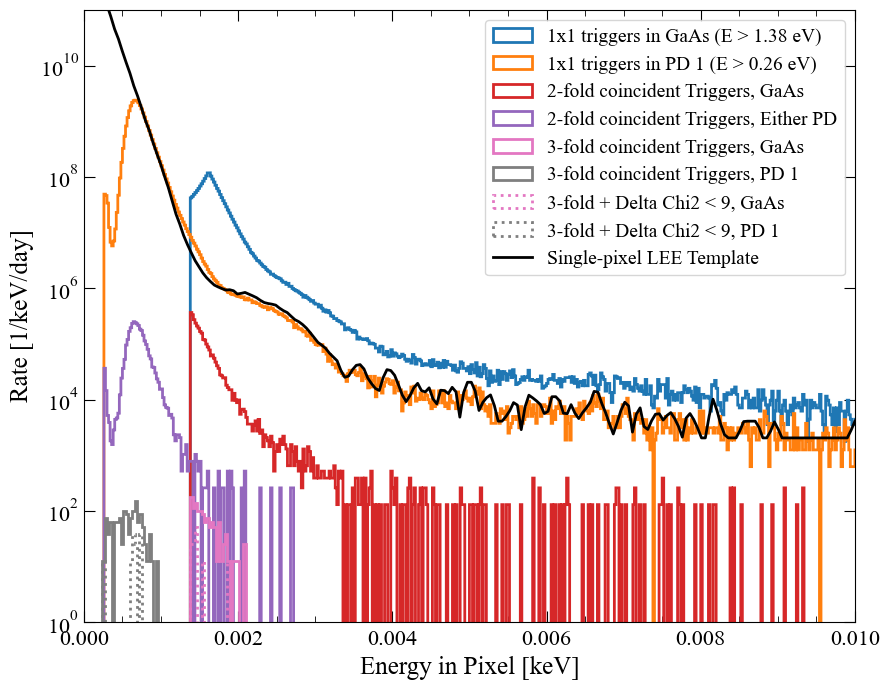

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(9, 7))
keV_bins = np.arange(0.1, 100, 0.02) * 1e-3


####################
# 1-fold coincidence
####################

single_pixel = E0_full > E_th_GaAs
duration_days = eff_exposure_GaAs_hours / 24
ax.hist(E0_full[single_pixel]*1e-3, bins=keV_bins,
        weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C0', lw=2,
        label=f'1x1 triggers in GaAs (E > {E_th_GaAs:.2f} eV)')
hist_E_E0_single, bin_edges = np.histogram(E0_full[single_pixel]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days))
R_single_GaAs = sum(hist_E_E0_single * np.diff(bin_edges))
print(f'Effective 1-fold exposure in GaAs: {duration_days:.2f} days')

single_pixel = E1_full > E_th_PD
duration_days = eff_exposure_PD1_hours / 24
ax.hist(E1_full[single_pixel]*1e-3, bins=keV_bins,
        weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C1', lw=2,
        label=f'1x1 triggers in PD 1 (E > {E_th_PD:.2f} eV)')
hist_E_E1_single, bin_edges = np.histogram(E1_full[single_pixel]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days))
R_single_PD_A = sum(hist_E_E1_single * np.diff(bin_edges))
print(f'Effective 1-fold exposure in PD 1: {duration_days:.2f} days')

# ####################
# # 2-fold coincidence
# ####################

detected = (E0_full > E_th_GaAs) * (E1_full > E_th_PD) + (E0_full > E_th_GaAs) * (E2_full > E_th_PD)
detected_A = (E0_full > E_th_GaAs) * (E1_full > E_th_PD)
detected_2fold = np.copy(detected)

duration_days = eff_exposure_per_run_GaAs_hours * eff_exposure_per_run_PD1_hours / run_length_hours / 24 * n_runs
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C3', lw=2,
        label='2-fold coincident Triggers, GaAs')
ax.hist(E1_full[detected_A]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected_A), 2/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C4', lw=2,
        label='2-fold coincident Triggers, Either PD')

hist_E_2fold_PD, bin_edges = np.histogram(E1_full[detected_A]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected_A), 2/np.diff(keV_bins)[0]/duration_days))
hist_E_2fold_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_2fold = sum(hist_E_2fold_GaAs * np.diff(bin_edges))

print(f'Effective 2-fold exposure: {duration_days:.2f} days')

# Export to a file
E_save = 0.5 * (keV_bins[1:] + keV_bins[:-1])
np.savetxt(dirname + 'background_spectrum_2fold.txt',
           np.column_stack((E_save, hist_E_2fold_GaAs)),
           header='Energy [keV]     dRdE GaAs [1/keV/day]',
           fmt='%.4e')


# ####################
# # 3-fold coincidence
# ####################

keV_bins = np.arange(0, 3, 0.03) * 1e-3  # Reduce the number of bins for 3-fold coincidence histogram
detected = (E0_full > E_th_GaAs) * (E1_full > E_th_PD) * (E2_full > E_th_PD)
duration_days = eff_exposure_per_run_GaAs_hours * eff_exposure_per_run_PD1_hours**2 / run_length_hours**2 / 24 * n_runs
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C6', lw=2,
        label='3-fold coincident Triggers, GaAs')
ax.hist(E1_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C7', lw=2,
        label='3-fold coincident Triggers, PD 1')

hist_E_3fold_PD, bin_edges = np.histogram(E1_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
hist_E_3fold_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_3fold = sum(hist_E_3fold_GaAs * np.diff(bin_edges))

print(f'Effective 3-fold exposure: {duration_days:.2f} days')

# ####################
# # Adding delta delta cut
# ####################

detected = (E0_full > E_th_GaAs) * (E1_full > E_th_PD) * (E2_full > E_th_PD) * (delta_delta_full < 9)
detected_overall = np.copy(detected)
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C6', lw=2, linestyle=':',
        label='3-fold + Delta Chi2 < 9, GaAs')
ax.hist(E1_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C7', lw=2, linestyle=':',
        label='3-fold + Delta Chi2 < 9, PD 1')

hist_E_3fold_delta_PD, bin_edges = np.histogram(E1_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
hist_E_3fold_delta_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_3fold_delta = sum(hist_E_3fold_delta_GaAs * np.diff(bin_edges))

# Export to a file
E_save = 0.5 * (keV_bins[1:] + keV_bins[:-1])
np.savetxt(dirname + 'background_spectrum_3fold.txt',
           np.column_stack((E_save, hist_E_3fold_delta_GaAs)),
           header='Energy [keV]     dRdE GaAs [1/keV/day]',
           fmt='%.4e')

# ####################
# # Wrapping up
# ####################


E_arr = np.linspace(0.1, 10, 200) * 1e-3
dRdE_arr = run57_lee_bkgd(scale_by=1/LEE_improvement_GaAs)(E_arr) * 86400
ax.plot(E_arr, dRdE_arr, color='k', label='Single-pixel LEE Template', lw=2)

ax.set_yscale('log')
ax.set_xlabel('Energy in Pixel [keV]')
ax.set_ylabel('Rate [1/keV/day]')
ax.set_ylim([1e0, 1e11])
ax.set_xlim([0, 10e-3])

ax.legend(loc='best', fontsize=14)
fig.tight_layout()
fig.show()

print(f'\nRates [1/day]:')
print(f'1-fold in GaAs: {R_single_GaAs:.0f}')
print(f'1-fold in PD 1: {R_single_PD_A:.0f}')
print(f'2-fold in GaAs, with either PD: {R_coincident_2fold:.2e}')
print(f'3-fold in GaAs: {R_coincident_3fold:.2e}')
print(f'3-fold in GaAs with Delta Chi2 < 9: {R_coincident_3fold_delta:.2e}')

print('\nRaw Numbers:')
print(f'Number of detected events: {len(E0_full):,}')
print(f'Number of events passing the 2-fold cut: {sum(detected_2fold):,}')
print(f'Number of events passing all cuts: {sum(detected_overall):,}')



# NR Stretch

In [ ]:
### Load template
template = detprocess.Template(verbose=True)
template.load_hdf5('/home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5')

# Load shared 2x1 template to get the energy scale right, but we only use the left channel template shape and PSD
channel = 'Mv3025pcBigFinsLeft|Mv3025pcBigFinsRight'

templates_td, t_sec_template, metadata = template.get_template(channel, return_metadata=True, tag='shared')
templates_td = np.reshape(templates_td[0,0], (1,1,templates_td.shape[-1]))
_, _, f_frequencies = templates_td.shape
fs = metadata['sample_rate']
pretrig = metadata['nb_pretrigger_samples']

csd, freqs_csd, _ = template.get_csd(channel, fold=False, return_metadata=True, tag='default')
csd = np.reshape(csd[0,0], (1,1,csd.shape[-1]))


### Convert to multichannel format

# Rescale template so that the energy resolution per channel is some assumed value
base_energy_resolution = 0.3977  # eV; this is the resolution of the 1x1 shared template from Run 57
GaAs_energy_resolution = 0.164
PD_energy_resolution = 0.031
n_sigma = 4.0  # Number of sigma for the trigger

E_th_GaAs = n_sigma * GaAs_energy_resolution
E_th_PD = n_sigma * PD_energy_resolution

E_exposure_GaAs = E_th_GaAs # The energy cutoff to calculate effective exposure. Can be the threshold or some other value.
E_exposure_PD = 0.65

template_OF = np.zeros((3, 3, f_frequencies))
template_OF[0, 0, :] = np.copy(templates_td)
template_OF[1, 1, :] = np.copy(templates_td) 
template_OF[2, 2, :] = np.copy(templates_td)

csd_OF = np.zeros((3, 3, f_frequencies))
csd_OF[0, 0, :] = np.copy(csd) * (GaAs_energy_resolution / base_energy_resolution)**2
csd_OF[1, 1, :] = np.copy(csd) * (PD_energy_resolution / base_energy_resolution)**2
csd_OF[2, 2, :] = np.copy(csd) * (PD_energy_resolution / base_energy_resolution)**2


INFO: Loading filter data from file /home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5


In [ ]:
### Load the simulation parameters
run_length_hours = 6
dirname = 'stretch_performance_NR_like/'

E_max_PD_keV = 100e-3
E_max_GaAs_keV = 100e-3

LEE_improvement_PD = 400. # Per-volume improvement factor for the PD
LEE_volume_scale_PD = 4.5 # Ratio of PD volume to Run 57 Si volume

LEE_improvement_GaAs = 400. # Per-volume improvement factor for the GaAs
LEE_volume_scale_GaAs = 108. # Ratio of GaAs volume to Run 57 Si volume

# We probably don't change these
sim_trace_length = 1_250_000 * 10
sim_trace_length_s = sim_trace_length / fs  # Convert to seconds
n_simulations_per_run = int(np.floor(run_length_hours * 3600 / sim_trace_length_s))
n_traces_per_sim = int(sim_trace_length / f_frequencies)


In [ ]:
### Load the simulation results

E0_full = []
E1_full = []
E2_full = []
sim_number_full = []
trigger_time_full = []
delta_delta_full = []
detected_full = []

n_runs = 0
for run_id in range(50):
    fns = glob.glob(dirname + f'my_simulation_3fold_{run_id:02d}*.pkl')
    if len(fns) == 0:
        continue
    with open(fns[0], 'rb') as f:
        results = pickle.load(f)
        
        E0_full += [e for result in results for e in result[0]]
        E1_full += [e for result in results for e in result[1]]
        E2_full += [e for result in results for e in result[2]]
        sim_number_full += [e for result in results for e in result[3]]
        trigger_time_full += [e for result in results for e in result[4]]
        delta_delta_full += [e for result in results for e in result[5]]
        detected_full += [e for result in results for e in result[6]]
        
        n_runs += 1
        del results
    print(run_id)

print(f'Loaded {n_runs} runs of simulation results.')

E0_full = np.array(E0_full)
E1_full = np.array(E1_full)
E2_full = np.array(E2_full)
sim_number_full = np.array(sim_number_full)
trigger_time_full = np.array(trigger_time_full)
delta_delta_full = np.array(delta_delta_full)
detected_full = np.array(detected_full)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
Loaded 49 runs of simulation results.


In [ ]:
### Calculate the effective exposure in the GaAs and PD detectors, based on the observed triggers

# Exposure in a single PD detector
n_triggers_obs_PD1 = sum(E1_full > E_exposure_PD)
print(f'\nNumber of triggers observed in PD 1: {n_triggers_obs_PD1}')

E_above_th_PD1 = np.geomspace(E_exposure_PD * 1e-3, E_max_PD_keV, 250)
dRdE_above_th_PD1 = run57_lee_bkgd(scale_by=1/LEE_improvement_PD)(E_above_th_PD1)
R_above_th_PD1 = np.trapz(dRdE_above_th_PD1, E_above_th_PD1)
print(f'Expected rate of triggers in PD 1 above threshold: {R_above_th_PD1:.2e} Hz')

eff_exposure_PD1_hours = n_triggers_obs_PD1 / R_above_th_PD1 / 3600
print(f'Effective exposure in PD: {eff_exposure_PD1_hours:.2f} hours (no volume scaling or LEE improvement)')

# Exposure in the GaAs detector
n_triggers_obs_GaAs = sum(E0_full > E_exposure_GaAs)
print(f'\nNumber of triggers observed in GaAs: {n_triggers_obs_GaAs}')

E_above_th_GaAs = np.geomspace(E_exposure_GaAs * 1e-3, E_max_GaAs_keV, 250)
dRdE_above_th_GaAs = run57_lee_bkgd(scale_by=1/LEE_improvement_GaAs)(E_above_th_GaAs)
R_above_th_GaAs = np.trapz(dRdE_above_th_GaAs, E_above_th_GaAs)
print(f'Expected rate of triggers in GaAs above threshold: {R_above_th_GaAs:.2e} Hz')

eff_exposure_GaAs_hours = n_triggers_obs_GaAs / R_above_th_GaAs / 3600
print(f'Effective exposure in GaAs: {eff_exposure_GaAs_hours / 24:.2f} days (no volume scaling or LEE improvement)')

# Apply the LEE and volume scaling
print('\n##########################\n')
eff_exposure_PD1_hours /= LEE_volume_scale_PD
eff_exposure_per_run_PD1_hours = eff_exposure_PD1_hours / n_runs
eff_exposure_GaAs_hours /= LEE_volume_scale_GaAs
eff_exposure_per_run_GaAs_hours = eff_exposure_GaAs_hours / n_runs
print(f'Effective exposure in PD after LEE and volume scaling: {eff_exposure_PD1_hours:.2f} hours ({eff_exposure_per_run_PD1_hours:.2f} hours per run)')
print(f'Effective exposure in GaAs after LEE and volume scaling: {eff_exposure_GaAs_hours:.2f} hours ({eff_exposure_per_run_GaAs_hours:.2f} hours per run)')


Number of triggers observed in PD 1: 33275314
Expected rate of triggers in PD 1 above threshold: 2.67e-01 Hz
Effective exposure in PD: 34640.24 hours (no volume scaling or LEE improvement)

Number of triggers observed in GaAs: 10812704
Expected rate of triggers in GaAs above threshold: 2.53e-01 Hz
Effective exposure in GaAs: 495.49 days (no volume scaling or LEE improvement)

##########################

Effective exposure in PD after LEE and volume scaling: 7697.83 hours (157.10 hours per run)
Effective exposure in GaAs after LEE and volume scaling: 110.11 hours (2.25 hours per run)


Effective 1-fold exposure in GaAs: 4.59 days
Effective 1-fold exposure in PD 1: 320.74 days
Effective 2-fold exposure: 120.13 days
Effective 3-fold exposure: 3145.26 days

Rates [1/day]:
1-fold in GaAs: 2356783
1-fold in PD 1: 154736
2-fold in GaAs, with either PD: 8.06e+02
3-fold in GaAs: 1.98e-01
3-fold in GaAs with Delta Chi2 < 9: 6.68e-03

Raw Numbers:
Number of detected events: 113,727,714
Number of events passing the 2-fold cut: 96,841
Number of events passing all cuts: 21


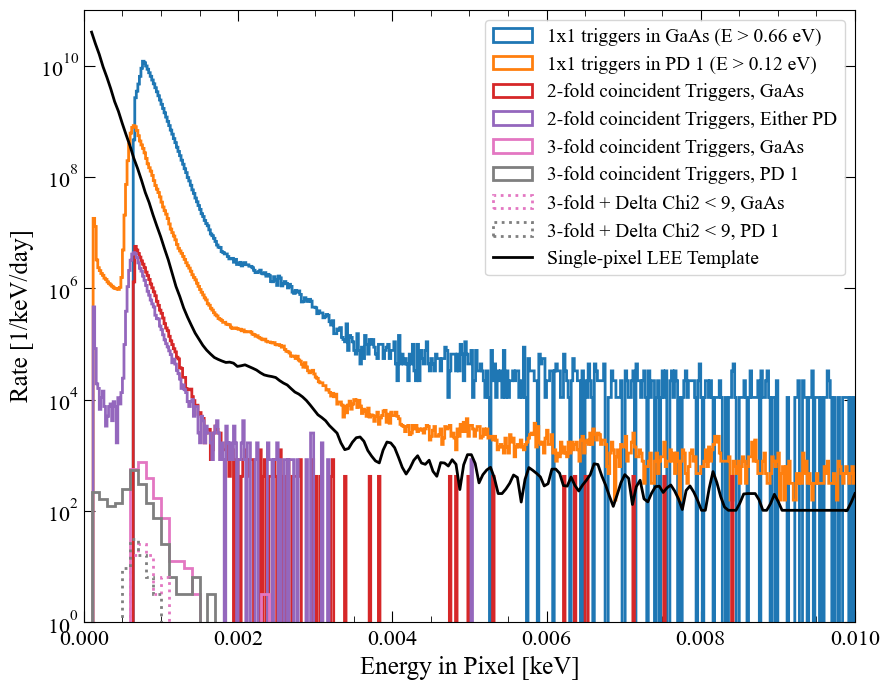

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(9, 7))
keV_bins = np.arange(0.1, 100, 0.02) * 1e-3


####################
# 1-fold coincidence
####################

single_pixel = E0_full > E_th_GaAs
duration_days = eff_exposure_GaAs_hours / 24
ax.hist(E0_full[single_pixel]*1e-3, bins=keV_bins,
        weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C0', lw=2,
        label=f'1x1 triggers in GaAs (E > {E_th_GaAs:.2f} eV)')
hist_E_E0_single, bin_edges = np.histogram(E0_full[single_pixel]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days))
R_single_GaAs = sum(hist_E_E0_single * np.diff(bin_edges))
print(f'Effective 1-fold exposure in GaAs: {duration_days:.2f} days')

single_pixel = E1_full > E_th_PD
duration_days = eff_exposure_PD1_hours / 24
ax.hist(E1_full[single_pixel]*1e-3, bins=keV_bins,
        weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C1', lw=2,
        label=f'1x1 triggers in PD 1 (E > {E_th_PD:.2f} eV)')
hist_E_E1_single, bin_edges = np.histogram(E1_full[single_pixel]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days))
R_single_PD_A = sum(hist_E_E1_single * np.diff(bin_edges))
print(f'Effective 1-fold exposure in PD 1: {duration_days:.2f} days')

# ####################
# # 2-fold coincidence
# ####################

detected = (E0_full > E_th_GaAs) * (E1_full > E_th_PD) + (E0_full > E_th_GaAs) * (E2_full > E_th_PD)
detected_A = (E0_full > E_th_GaAs) * (E1_full > E_th_PD)
detected_2fold = np.copy(detected)

duration_days = eff_exposure_per_run_GaAs_hours * eff_exposure_per_run_PD1_hours / run_length_hours / 24 * n_runs
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C3', lw=2,
        label='2-fold coincident Triggers, GaAs')
ax.hist(E1_full[detected_A]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected_A), 2/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C4', lw=2,
        label='2-fold coincident Triggers, Either PD')

hist_E_2fold_PD, bin_edges = np.histogram(E1_full[detected_A]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected_A), 2/np.diff(keV_bins)[0]/duration_days))
hist_E_2fold_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_2fold = sum(hist_E_2fold_GaAs * np.diff(bin_edges))

print(f'Effective 2-fold exposure: {duration_days:.2f} days')

# Export to a file
E_save = 0.5 * (keV_bins[1:] + keV_bins[:-1])
np.savetxt(dirname + 'background_spectrum_2fold.txt',
           np.column_stack((E_save, hist_E_2fold_GaAs)),
           header='Energy [keV]     dRdE GaAs [1/keV/day]',
           fmt='%.4e')


# ####################
# # 3-fold coincidence
# ####################

keV_bins = np.arange(0, 3, 0.1) * 1e-3  # Reduce the number of bins for 3-fold coincidence histogram
detected = (E0_full > E_th_GaAs) * (E1_full > E_th_PD) * (E2_full > E_th_PD)
duration_days = eff_exposure_per_run_GaAs_hours * eff_exposure_per_run_PD1_hours**2 / run_length_hours**2 / 24 * n_runs
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C6', lw=2,
        label='3-fold coincident Triggers, GaAs')
ax.hist(E1_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C7', lw=2,
        label='3-fold coincident Triggers, PD 1')

hist_E_3fold_PD, bin_edges = np.histogram(E1_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
hist_E_3fold_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_3fold = sum(hist_E_3fold_GaAs * np.diff(bin_edges))

print(f'Effective 3-fold exposure: {duration_days:.2f} days')

# ####################
# # Adding delta delta cut
# ####################

detected = (E0_full > E_th_GaAs) * (E1_full > E_th_PD) * (E2_full > E_th_PD) * (delta_delta_full < 9)
detected_overall = np.copy(detected)
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C6', lw=2, linestyle=':',
        label='3-fold + Delta Chi2 < 9, GaAs')
ax.hist(E1_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C7', lw=2, linestyle=':',
        label='3-fold + Delta Chi2 < 9, PD 1')

hist_E_3fold_delta_PD, bin_edges = np.histogram(E1_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
hist_E_3fold_delta_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_3fold_delta = sum(hist_E_3fold_delta_GaAs * np.diff(bin_edges))

# Export to a file
E_save = 0.5 * (keV_bins[1:] + keV_bins[:-1])
np.savetxt(dirname + 'background_spectrum_3fold.txt',
           np.column_stack((E_save, hist_E_3fold_delta_GaAs)),
           header='Energy [keV]     dRdE GaAs [1/keV/day]',
           fmt='%.4e')

# ####################
# # Wrapping up
# ####################


E_arr = np.linspace(0.1, 10, 200) * 1e-3
dRdE_arr = run57_lee_bkgd(scale_by=1/LEE_improvement_GaAs)(E_arr) * 86400
ax.plot(E_arr, dRdE_arr, color='k', label='Single-pixel LEE Template', lw=2)

ax.set_yscale('log')
ax.set_xlabel('Energy in Pixel [keV]')
ax.set_ylabel('Rate [1/keV/day]')
ax.set_ylim([1e0, 1e11])
ax.set_xlim([0, 10e-3])

ax.legend(loc='best', fontsize=14)
fig.tight_layout()
fig.show()

print(f'\nRates [1/day]:')
print(f'1-fold in GaAs: {R_single_GaAs:.0f}')
print(f'1-fold in PD 1: {R_single_PD_A:.0f}')
print(f'2-fold in GaAs, with either PD: {R_coincident_2fold:.2e}')
print(f'3-fold in GaAs: {R_coincident_3fold:.2e}')
print(f'3-fold in GaAs with Delta Chi2 < 9: {R_coincident_3fold_delta:.2e}')

print('\nRaw Numbers:')
print(f'Number of detected events: {len(E0_full):,}')
print(f'Number of events passing the 2-fold cut: {sum(detected_2fold):,}')
print(f'Number of events passing all cuts: {sum(detected_overall):,}')



# NR Requirement Bigger

In [ ]:
### Load template
template = detprocess.Template(verbose=True)
template.load_hdf5('/home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5')

# Load shared 2x1 template to get the energy scale right, but we only use the left channel template shape and PSD
channel = 'Mv3025pcBigFinsLeft|Mv3025pcBigFinsRight'

templates_td, t_sec_template, metadata = template.get_template(channel, return_metadata=True, tag='shared')
templates_td = np.reshape(templates_td[0,0], (1,1,templates_td.shape[-1]))
_, _, f_frequencies = templates_td.shape
fs = metadata['sample_rate']
pretrig = metadata['nb_pretrigger_samples']

csd, freqs_csd, _ = template.get_csd(channel, fold=False, return_metadata=True, tag='default')
csd = np.reshape(csd[0,0], (1,1,csd.shape[-1]))


### Convert to multichannel format

# Rescale template so that the energy resolution per channel is some assumed value
base_energy_resolution = 0.3977  # eV; this is the resolution of the 1x1 shared template from Run 57
PD_energy_resolution = 0.612
GaAs_energy_resolution = 3.271
n_sigma = 3.  # Number of sigma for the trigger

E_th_GaAs = n_sigma * GaAs_energy_resolution
E_th_PD = n_sigma * PD_energy_resolution

E_exposure_GaAs = E_th_GaAs # The energy cutoff to calculate effective exposure. Can be the threshold or some other value.
E_exposure_PD = E_th_PD

template_OF = np.zeros((3, 3, f_frequencies))
template_OF[0, 0, :] = np.copy(templates_td)
template_OF[1, 1, :] = np.copy(templates_td) 
template_OF[2, 2, :] = np.copy(templates_td)

csd_OF = np.zeros((3, 3, f_frequencies))
csd_OF[0, 0, :] = np.copy(csd) * (GaAs_energy_resolution / base_energy_resolution)**2
csd_OF[1, 1, :] = np.copy(csd) * (PD_energy_resolution / base_energy_resolution)**2
csd_OF[2, 2, :] = np.copy(csd) * (PD_energy_resolution / base_energy_resolution)**2


INFO: Loading filter data from file /home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5


In [ ]:
### Load the simulation parameters
run_length_hours = 6
dirname = 'required_performance_bigger_3sigma/'

E_max_PD_keV = 100e-3
E_max_GaAs_keV = 100e-3

LEE_improvement_PD = 1. # Per-volume improvement factor for the PD
LEE_volume_scale_PD = 4.5 # Ratio of PD volume to Run 57 Si volume

LEE_improvement_GaAs = 1. # Per-volume improvement factor for the GaAs
LEE_volume_scale_GaAs = 108. # Ratio of GaAs volume to Run 57 Si volume

# We probably don't change these
sim_trace_length = 1_250_000 * 10
sim_trace_length_s = sim_trace_length / fs  # Convert to seconds
n_simulations_per_run = int(np.floor(run_length_hours * 3600 / sim_trace_length_s))
n_traces_per_sim = int(sim_trace_length / f_frequencies)


In [ ]:
### Load the simulation results

E0_full = []
E1_full = []
E2_full = []
sim_number_full = []
trigger_time_full = []
delta_delta_full = []
detected_full = []

n_runs = 0
for run_id in range(50):
    fns = glob.glob(dirname + f'my_simulation_3fold_{run_id:02d}*.pkl')
    if len(fns) == 0:
        continue
    with open(fns[0], 'rb') as f:
        results = pickle.load(f)
        
        E0_full += [e for result in results for e in result[0]]
        E1_full += [e for result in results for e in result[1]]
        E2_full += [e for result in results for e in result[2]]
        sim_number_full += [e for result in results for e in result[3]]
        trigger_time_full += [e for result in results for e in result[4]]
        delta_delta_full += [e for result in results for e in result[5]]
        detected_full += [e for result in results for e in result[6]]
        
        n_runs += 1
        del results
    print(run_id)

print(f'Loaded {n_runs} runs of simulation results.')

E0_full = np.array(E0_full)
E1_full = np.array(E1_full)
E2_full = np.array(E2_full)
sim_number_full = np.array(sim_number_full)
trigger_time_full = np.array(trigger_time_full)
delta_delta_full = np.array(delta_delta_full)
detected_full = np.array(detected_full)


0
1
2
3
4
5
6
7
8
9
Loaded 10 runs of simulation results.


In [ ]:
### Calculate the effective exposure in the GaAs and PD detectors, based on the observed triggers

# Exposure in a single PD detector
n_triggers_obs_PD1 = sum(E1_full > E_exposure_PD)
print(f'\nNumber of triggers observed in PD 1: {n_triggers_obs_PD1}')

E_above_th_PD1 = np.geomspace(E_exposure_PD * 1e-3, E_max_PD_keV, 250)
dRdE_above_th_PD1 = run57_lee_bkgd(scale_by=LEE_volume_scale_PD/LEE_improvement_PD)(E_above_th_PD1)
R_above_th_PD1 = np.trapz(dRdE_above_th_PD1, E_above_th_PD1)
print(f'Expected rate of triggers in PD 1 above threshold: {R_above_th_PD1:.2e} Hz')

eff_exposure_PD1_hours = n_triggers_obs_PD1 / R_above_th_PD1 / 3600
print(f'Effective exposure in PD: {eff_exposure_PD1_hours:.2f} hours (no volume scaling or LEE improvement)')

# Exposure in the GaAs detector
n_triggers_obs_GaAs = sum(E0_full > E_exposure_GaAs)
print(f'\nNumber of triggers observed in GaAs: {n_triggers_obs_GaAs}')

E_above_th_GaAs = np.geomspace(E_exposure_GaAs * 1e-3, E_max_GaAs_keV, 250)
dRdE_above_th_GaAs = run57_lee_bkgd(scale_by=LEE_volume_scale_GaAs/LEE_improvement_GaAs)(E_above_th_GaAs)
R_above_th_GaAs = np.trapz(dRdE_above_th_GaAs, E_above_th_GaAs)
print(f'Expected rate of triggers in GaAs above threshold: {R_above_th_GaAs:.2e} Hz')

eff_exposure_GaAs_hours = n_triggers_obs_GaAs / R_above_th_GaAs / 3600
print(f'Effective exposure in GaAs: {eff_exposure_GaAs_hours / 24:.2f} days (no volume scaling or LEE improvement)')

# Apply the LEE and volume scaling
print('\n##########################\n')
#eff_exposure_PD1_hours /= LEE_volume_scale_PD
eff_exposure_per_run_PD1_hours = eff_exposure_PD1_hours / n_runs
#eff_exposure_GaAs_hours /= LEE_volume_scale_GaAs
eff_exposure_per_run_GaAs_hours = eff_exposure_GaAs_hours / n_runs
print(f'Effective exposure in PD after LEE and volume scaling: {eff_exposure_PD1_hours:.2f} hours ({eff_exposure_per_run_PD1_hours:.2f} hours per run)')
print(f'Effective exposure in GaAs after LEE and volume scaling: {eff_exposure_GaAs_hours:.2f} hours ({eff_exposure_per_run_GaAs_hours:.2f} hours per run)')


Number of triggers observed in PD 1: 3595382
Expected rate of triggers in PD 1 above threshold: 7.60e-01 Hz
Effective exposure in PD: 1314.47 hours (no volume scaling or LEE improvement)

Number of triggers observed in GaAs: 8241393
Expected rate of triggers in GaAs above threshold: 6.05e-01 Hz
Effective exposure in GaAs: 157.69 days (no volume scaling or LEE improvement)

##########################

Effective exposure in PD after LEE and volume scaling: 1314.47 hours (131.45 hours per run)
Effective exposure in GaAs after LEE and volume scaling: 3784.52 hours (378.45 hours per run)


Effective 1-fold exposure in GaAs: 157.69 days
Effective 1-fold exposure in PD 1: 54.77 days
Effective 2-fold exposure: 3454.62 days
Effective 3-fold exposure: 75683.57 days

Rates [1/day]:
1-fold in GaAs: 52147
1-fold in PD 1: 65645
2-fold in GaAs, with either PD: 2.28e+01
3-fold in GaAs: 1.27e-03
3-fold in GaAs with Delta Chi2 < 9: 1.15e-03

Raw Numbers:
Number of detected events: 27,944,802
Number of events passing the 2-fold cut: 78,869
Number of events passing all cuts: 87


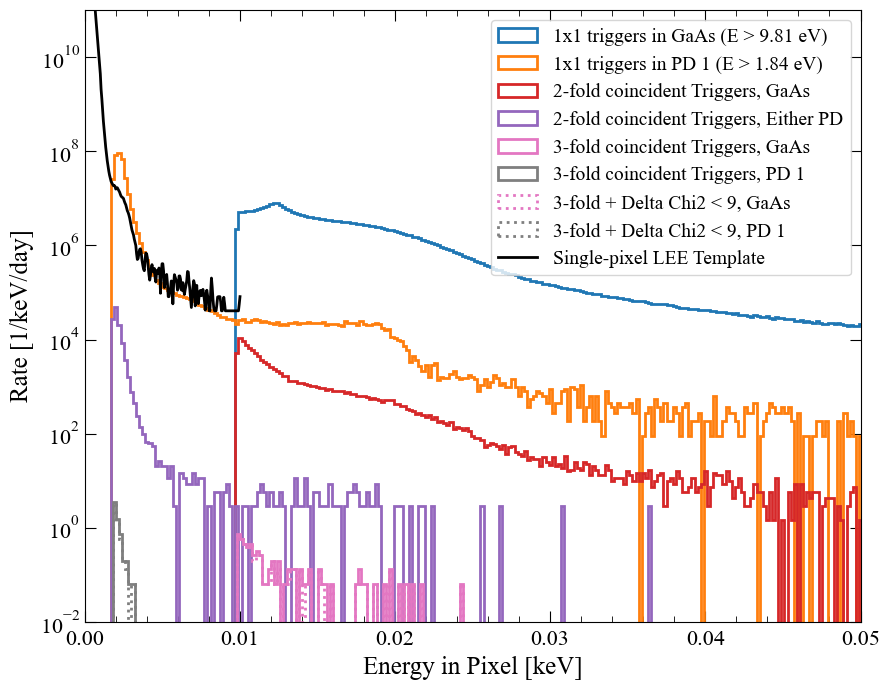

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(9, 7))
keV_bins = np.arange(0.1, 100, 0.2) * 1e-3


####################
# 1-fold coincidence
####################

single_pixel = E0_full > E_th_GaAs
duration_days = eff_exposure_GaAs_hours / 24
ax.hist(E0_full[single_pixel]*1e-3, bins=keV_bins,
        weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C0', lw=2,
        label=f'1x1 triggers in GaAs (E > {E_th_GaAs:.2f} eV)')
hist_E_E0_single, bin_edges = np.histogram(E0_full[single_pixel]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days))
R_single_GaAs = sum(hist_E_E0_single * np.diff(bin_edges))
print(f'Effective 1-fold exposure in GaAs: {duration_days:.2f} days')

single_pixel = E1_full > E_th_PD
duration_days = eff_exposure_PD1_hours / 24
ax.hist(E1_full[single_pixel]*1e-3, bins=keV_bins,
        weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C1', lw=2,
        label=f'1x1 triggers in PD 1 (E > {E_th_PD:.2f} eV)')
hist_E_E1_single, bin_edges = np.histogram(E1_full[single_pixel]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days))
R_single_PD_A = sum(hist_E_E1_single * np.diff(bin_edges))
print(f'Effective 1-fold exposure in PD 1: {duration_days:.2f} days')

# ####################
# # 2-fold coincidence
# ####################

detected = (E0_full > E_th_GaAs) * (E1_full > E_th_PD) + (E0_full > E_th_GaAs) * (E2_full > E_th_PD)
detected_A = (E0_full > E_th_GaAs) * (E1_full > E_th_PD)
detected_2fold = np.copy(detected)

duration_days = eff_exposure_per_run_GaAs_hours * eff_exposure_per_run_PD1_hours / run_length_hours / 24 * n_runs
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C3', lw=2,
        label='2-fold coincident Triggers, GaAs')
ax.hist(E1_full[detected_A]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected_A), 2/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C4', lw=2,
        label='2-fold coincident Triggers, Either PD')

hist_E_2fold_PD, bin_edges = np.histogram(E1_full[detected_A]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected_A), 2/np.diff(keV_bins)[0]/duration_days))
hist_E_2fold_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_2fold = sum(hist_E_2fold_GaAs * np.diff(bin_edges))

print(f'Effective 2-fold exposure: {duration_days:.2f} days')

# Export to a file
E_save = 0.5 * (keV_bins[1:] + keV_bins[:-1])
np.savetxt(dirname + 'background_spectrum_2fold.txt',
           np.column_stack((E_save, hist_E_2fold_GaAs)),
           header='Energy [keV]     dRdE GaAs [1/keV/day]',
           fmt='%.4e')


# ####################
# # 3-fold coincidence
# ####################

keV_bins = np.arange(0, 50, 0.2) * 1e-3  # Reduce the number of bins for 3-fold coincidence histogram
detected = (E0_full > E_th_GaAs) * (E1_full > E_th_PD) * (E2_full > E_th_PD)
duration_days = eff_exposure_per_run_GaAs_hours * eff_exposure_per_run_PD1_hours**2 / run_length_hours**2 / 24 * n_runs
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C6', lw=2,
        label='3-fold coincident Triggers, GaAs')
ax.hist(E1_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C7', lw=2,
        label='3-fold coincident Triggers, PD 1')

hist_E_3fold_PD, bin_edges = np.histogram(E1_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
hist_E_3fold_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_3fold = sum(hist_E_3fold_GaAs * np.diff(bin_edges))

print(f'Effective 3-fold exposure: {duration_days:.2f} days')

# ####################
# # Adding delta delta cut
# ####################

detected = (E0_full > E_th_GaAs) * (E1_full > E_th_PD) * (E2_full > E_th_PD) * (delta_delta_full < 9)
detected_overall = np.copy(detected)
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C6', lw=2, linestyle=':',
        label='3-fold + Delta Chi2 < 9, GaAs')
ax.hist(E1_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C7', lw=2, linestyle=':',
        label='3-fold + Delta Chi2 < 9, PD 1')

hist_E_3fold_delta_PD, bin_edges = np.histogram(E1_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
hist_E_3fold_delta_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_3fold_delta = sum(hist_E_3fold_delta_GaAs * np.diff(bin_edges))

# Export to a file
E_save = 0.5 * (keV_bins[1:] + keV_bins[:-1])
np.savetxt(dirname + 'background_spectrum_3fold.txt',
           np.column_stack((E_save, hist_E_3fold_delta_GaAs)),
           header='Energy [keV]     dRdE GaAs [1/keV/day]',
           fmt='%.4e')

# ####################
# # Wrapping up
# ####################


E_arr = np.linspace(0.1, 10, 200) * 1e-3
dRdE_arr = run57_lee_bkgd(scale_by=1/LEE_improvement_GaAs)(E_arr) * 86400
ax.plot(E_arr, dRdE_arr, color='k', label='Single-pixel LEE Template', lw=2)

ax.set_yscale('log')
ax.set_xlabel('Energy in Pixel [keV]')
ax.set_ylabel('Rate [1/keV/day]')
ax.set_ylim([1e-2, 1e11])
ax.set_xlim([0, 50e-3])

ax.legend(loc='best', fontsize=14)
fig.tight_layout()
fig.show()

print(f'\nRates [1/day]:')
print(f'1-fold in GaAs: {R_single_GaAs:.0f}')
print(f'1-fold in PD 1: {R_single_PD_A:.0f}')
print(f'2-fold in GaAs, with either PD: {R_coincident_2fold:.2e}')
print(f'3-fold in GaAs: {R_coincident_3fold:.2e}')
print(f'3-fold in GaAs with Delta Chi2 < 9: {R_coincident_3fold_delta:.2e}')

print('\nRaw Numbers:')
print(f'Number of detected events: {len(E0_full):,}')
print(f'Number of events passing the 2-fold cut: {sum(detected_2fold):,}')
print(f'Number of events passing all cuts: {sum(detected_overall):,}')



# ER Requirement

In [ ]:
### Load template
template = detprocess.Template(verbose=True)
template.load_hdf5('/home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5')

# Load shared 2x1 template to get the energy scale right, but we only use the left channel template shape and PSD
channel = 'Mv3025pcBigFinsLeft|Mv3025pcBigFinsRight'

templates_td, t_sec_template, metadata = template.get_template(channel, return_metadata=True, tag='shared')
templates_td = np.reshape(templates_td[0,0], (1,1,templates_td.shape[-1]))
_, _, f_frequencies = templates_td.shape
fs = metadata['sample_rate']
pretrig = metadata['nb_pretrigger_samples']

csd, freqs_csd, _ = template.get_csd(channel, fold=False, return_metadata=True, tag='default')
csd = np.reshape(csd[0,0], (1,1,csd.shape[-1]))


### Convert to multichannel format

# Rescale template so that the energy resolution per channel is some assumed value
base_energy_resolution = 0.3977  # eV; this is the resolution of the 1x1 shared template from Run 57
GaAs_energy_resolution = 0.282
PD_energy_resolution = 0.183
n_sigma = 4.0  # Number of sigma for the trigger

E_th_GaAs = n_sigma * GaAs_energy_resolution
E_th_PD = n_sigma * PD_energy_resolution

E_exposure_GaAs = E_th_GaAs # The energy cutoff to calculate effective exposure. Can be the threshold or some other value.
E_exposure_PD = E_th_PD

template_OF = np.zeros((3, 3, f_frequencies))
template_OF[0, 0, :] = np.copy(templates_td)
template_OF[1, 1, :] = np.copy(templates_td) 
template_OF[2, 2, :] = np.copy(templates_td)

csd_OF = np.zeros((3, 3, f_frequencies))
csd_OF[0, 0, :] = np.copy(csd) * (GaAs_energy_resolution / base_energy_resolution)**2
csd_OF[1, 1, :] = np.copy(csd) * (PD_energy_resolution / base_energy_resolution)**2
csd_OF[2, 2, :] = np.copy(csd) * (PD_energy_resolution / base_energy_resolution)**2


INFO: Loading filter data from file /home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5


In [ ]:
### Load the simulation parameters
run_length_hours = 6
dirname = 'required_performance_ER_like/'

E_max_PD_keV = 100e-3
E_max_GaAs_keV = 100e-3

LEE_improvement_PD = 1. # Per-volume improvement factor for the PD
LEE_volume_scale_PD = 0.32 # Ratio of PD volume to Run 57 Si volume

LEE_improvement_GaAs = 1. # Per-volume improvement factor for the GaAs
LEE_volume_scale_GaAs = 0.64 # Ratio of GaAs volume to Run 57 Si volume

# We probably don't change these
sim_trace_length = 1_250_000 * 10
sim_trace_length_s = sim_trace_length / fs  # Convert to seconds
n_simulations_per_run = int(np.floor(run_length_hours * 3600 / sim_trace_length_s))
n_traces_per_sim = int(sim_trace_length / f_frequencies)

In [ ]:
### Load the simulation results

E0_full = []
E1_full = []
E2_full = []
sim_number_full = []
trigger_time_full = []
delta_delta_full = []
detected_full = []

n_runs = 0
for run_id in range(50):
    fns = glob.glob(dirname + f'my_simulation_3fold_{run_id:02d}*.pkl')
    if len(fns) == 0:
        continue
    with open(fns[0], 'rb') as f:
        results = pickle.load(f)
        
        E0_full += [e for result in results for e in result[0]]
        E1_full += [e for result in results for e in result[1]]
        E2_full += [e for result in results for e in result[2]]
        sim_number_full += [e for result in results for e in result[3]]
        trigger_time_full += [e for result in results for e in result[4]]
        delta_delta_full += [e for result in results for e in result[5]]
        detected_full += [e for result in results for e in result[6]]
        
        n_runs += 1
        del results
    print(run_id)

print(f'Loaded {n_runs} runs of simulation results.')

E0_full = np.array(E0_full)
E1_full = np.array(E1_full)
E2_full = np.array(E2_full)
sim_number_full = np.array(sim_number_full)
trigger_time_full = np.array(trigger_time_full)
delta_delta_full = np.array(delta_delta_full)
detected_full = np.array(detected_full)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
Loaded 50 runs of simulation results.


In [ ]:
### Calculate the effective exposure in the GaAs and PD detectors, based on the observed triggers

# Exposure in a single PD detector
n_triggers_obs_PD1 = sum(E1_full > E_exposure_PD)
print(f'\nNumber of triggers observed in PD 1: {n_triggers_obs_PD1}')

E_above_th_PD1 = np.geomspace(E_exposure_PD * 1e-3, E_max_PD_keV, 250)
dRdE_above_th_PD1 = run57_lee_bkgd(scale_by=1/LEE_improvement_PD)(E_above_th_PD1)
R_above_th_PD1 = np.trapz(dRdE_above_th_PD1, E_above_th_PD1)
print(f'Expected rate of triggers in PD 1 above threshold: {R_above_th_PD1:.2e} Hz')

eff_exposure_PD1_hours = n_triggers_obs_PD1 / R_above_th_PD1 / 3600
print(f'Effective exposure in PD: {eff_exposure_PD1_hours:.2f} hours (no volume scaling or LEE improvement)')

# Exposure in the GaAs detector
n_triggers_obs_GaAs = sum(E0_full > E_exposure_GaAs)
print(f'\nNumber of triggers observed in GaAs: {n_triggers_obs_GaAs}')

E_above_th_GaAs = np.geomspace(E_exposure_GaAs * 1e-3, E_max_GaAs_keV, 250)
dRdE_above_th_GaAs = run57_lee_bkgd(scale_by=1/LEE_improvement_GaAs)(E_above_th_GaAs)
R_above_th_GaAs = np.trapz(dRdE_above_th_GaAs, E_above_th_GaAs)
print(f'Expected rate of triggers in GaAs above threshold: {R_above_th_GaAs:.2e} Hz')

eff_exposure_GaAs_hours = n_triggers_obs_GaAs / R_above_th_GaAs / 3600
print(f'Effective exposure in GaAs: {eff_exposure_GaAs_hours / 24:.2f} days (no volume scaling or LEE improvement)')

# Apply the LEE and volume scaling
print('\n##########################\n')
eff_exposure_PD1_hours /= LEE_volume_scale_PD
eff_exposure_per_run_PD1_hours = eff_exposure_PD1_hours / n_runs
eff_exposure_GaAs_hours /= LEE_volume_scale_GaAs
eff_exposure_per_run_GaAs_hours = eff_exposure_GaAs_hours / n_runs
print(f'Effective exposure in PD after LEE and volume scaling: {eff_exposure_PD1_hours:.2f} hours ({eff_exposure_per_run_PD1_hours:.2f} hours per run)')
print(f'Effective exposure in GaAs after LEE and volume scaling: {eff_exposure_GaAs_hours:.2f} hours ({eff_exposure_per_run_GaAs_hours:.2f} hours per run)')


Number of triggers observed in PD 1: 33473464
Expected rate of triggers in PD 1 above threshold: 4.93e+01 Hz
Effective exposure in PD: 188.79 hours (no volume scaling or LEE improvement)

Number of triggers observed in GaAs: 13920640
Expected rate of triggers in GaAs above threshold: 1.32e+00 Hz
Effective exposure in GaAs: 121.96 days (no volume scaling or LEE improvement)

##########################

Effective exposure in PD after LEE and volume scaling: 589.98 hours (11.80 hours per run)
Effective exposure in GaAs after LEE and volume scaling: 4573.61 hours (91.47 hours per run)


Effective 1-fold exposure in GaAs: 190.57 days
Effective 1-fold exposure in PD 1: 24.58 days
Effective 2-fold exposure: 374.77 days
Effective 3-fold exposure: 737.01 days

Rates [1/day]:
1-fold in GaAs: 73048
1-fold in PD 1: 1361689
2-fold in GaAs, with either PD: 3.57e+02
3-fold in GaAs: 3.03e-01
3-fold in GaAs with Delta Chi2 < 9: 1.71e-01

Raw Numbers:
Number of detected events: 84,336,397
Number of events passing the 2-fold cut: 133,804
Number of events passing all cuts: 126


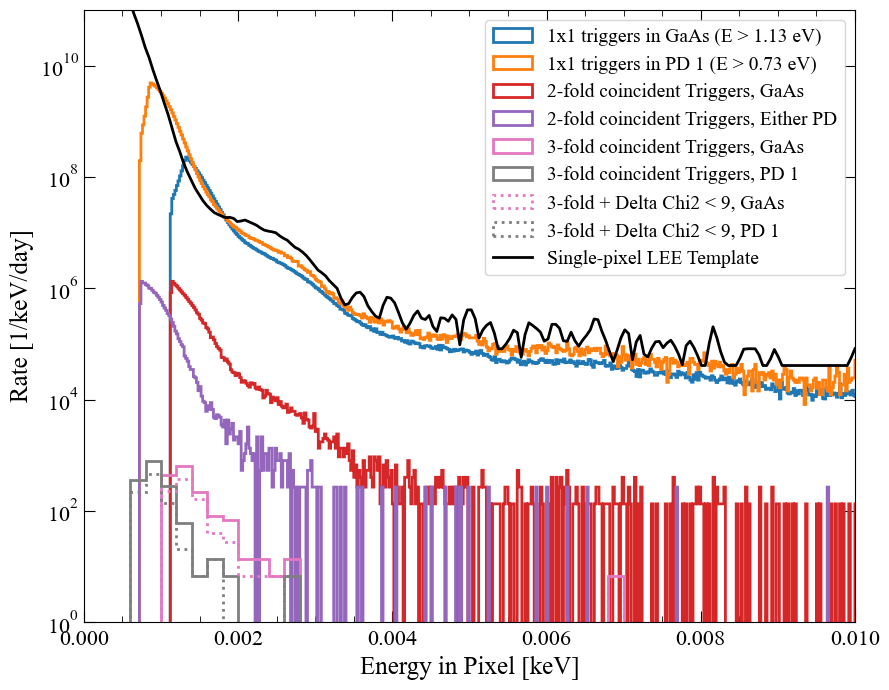

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(9, 7))
keV_bins = np.arange(0.1, 100, 0.02) * 1e-3


####################
# 1-fold coincidence
####################

single_pixel = E0_full > E_th_GaAs
duration_days = eff_exposure_GaAs_hours / 24
ax.hist(E0_full[single_pixel]*1e-3, bins=keV_bins,
        weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C0', lw=2,
        label=f'1x1 triggers in GaAs (E > {E_th_GaAs:.2f} eV)')
hist_E_E0_single, bin_edges = np.histogram(E0_full[single_pixel]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days))
R_single_GaAs = sum(hist_E_E0_single * np.diff(bin_edges))
print(f'Effective 1-fold exposure in GaAs: {duration_days:.2f} days')

single_pixel = E1_full > E_th_PD
duration_days = eff_exposure_PD1_hours / 24
ax.hist(E1_full[single_pixel]*1e-3, bins=keV_bins,
        weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C1', lw=2,
        label=f'1x1 triggers in PD 1 (E > {E_th_PD:.2f} eV)')
hist_E_E1_single, bin_edges = np.histogram(E1_full[single_pixel]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days))
R_single_PD_A = sum(hist_E_E1_single * np.diff(bin_edges))
print(f'Effective 1-fold exposure in PD 1: {duration_days:.2f} days')

# ####################
# # 2-fold coincidence
# ####################

detected = (E0_full > E_th_GaAs) * (E1_full > E_th_PD) + (E0_full > E_th_GaAs) * (E2_full > E_th_PD)
detected_A = (E0_full > E_th_GaAs) * (E1_full > E_th_PD)
detected_2fold = np.copy(detected)

duration_days = eff_exposure_per_run_GaAs_hours * eff_exposure_per_run_PD1_hours / run_length_hours / 24 * n_runs
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C3', lw=2,
        label='2-fold coincident Triggers, GaAs')
ax.hist(E1_full[detected_A]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected_A), 2/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C4', lw=2,
        label='2-fold coincident Triggers, Either PD')

hist_E_2fold_PD, bin_edges = np.histogram(E1_full[detected_A]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected_A), 2/np.diff(keV_bins)[0]/duration_days))
hist_E_2fold_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_2fold = sum(hist_E_2fold_GaAs * np.diff(bin_edges))

print(f'Effective 2-fold exposure: {duration_days:.2f} days')

# Export to a file
E_save = 0.5 * (keV_bins[1:] + keV_bins[:-1])
np.savetxt(dirname + 'background_spectrum_2fold.txt',
           np.column_stack((E_save, hist_E_2fold_GaAs)),
           header='Energy [keV]     dRdE GaAs [1/keV/day]',
           fmt='%.4e')


# ####################
# # 3-fold coincidence
# ####################

keV_bins = np.arange(0, 10, 0.2) * 1e-3  # Reduce the number of bins for 3-fold coincidence histogram
detected = (E0_full > E_th_GaAs) * (E1_full > E_th_PD) * (E2_full > E_th_PD)
duration_days = eff_exposure_per_run_GaAs_hours * eff_exposure_per_run_PD1_hours**2 / run_length_hours**2 / 24 * n_runs
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C6', lw=2,
        label='3-fold coincident Triggers, GaAs')
ax.hist(E1_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C7', lw=2,
        label='3-fold coincident Triggers, PD 1')

hist_E_3fold_PD, bin_edges = np.histogram(E1_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
hist_E_3fold_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_3fold = sum(hist_E_3fold_GaAs * np.diff(bin_edges))

print(f'Effective 3-fold exposure: {duration_days:.2f} days')

# ####################
# # Adding delta delta cut
# ####################

detected = (E0_full > E_th_GaAs) * (E1_full > E_th_PD) * (E2_full > E_th_PD) * (delta_delta_full < 9)
detected_overall = np.copy(detected)
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C6', lw=2, linestyle=':',
        label='3-fold + Delta Chi2 < 9, GaAs')
ax.hist(E1_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C7', lw=2, linestyle=':',
        label='3-fold + Delta Chi2 < 9, PD 1')

hist_E_3fold_delta_PD, bin_edges = np.histogram(E1_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
hist_E_3fold_delta_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_3fold_delta = sum(hist_E_3fold_delta_GaAs * np.diff(bin_edges))

# Export to a file
E_save = 0.5 * (keV_bins[1:] + keV_bins[:-1])
np.savetxt(dirname + 'background_spectrum_3fold.txt',
           np.column_stack((E_save, hist_E_3fold_delta_GaAs)),
           header='Energy [keV]     dRdE GaAs [1/keV/day]',
           fmt='%.4e')

# ####################
# # Wrapping up
# ####################


E_arr = np.linspace(0.1, 10, 200) * 1e-3
dRdE_arr = run57_lee_bkgd(scale_by=1/LEE_improvement_GaAs)(E_arr)
ax.plot(E_arr, dRdE_arr * 86400, color='k', label='Single-pixel LEE Template', lw=2)

ax.set_yscale('log')
ax.set_xlabel('Energy in Pixel [keV]')
ax.set_ylabel('Rate [1/keV/day]')
ax.set_ylim([1e0, 1e11])
ax.set_xlim([0, 10e-3])

ax.legend(loc='best', fontsize=14)
fig.tight_layout()
fig.show()

print(f'\nRates [1/day]:')
print(f'1-fold in GaAs: {R_single_GaAs:.0f}')
print(f'1-fold in PD 1: {R_single_PD_A:.0f}')
print(f'2-fold in GaAs, with either PD: {R_coincident_2fold:.2e}')
print(f'3-fold in GaAs: {R_coincident_3fold:.2e}')
print(f'3-fold in GaAs with Delta Chi2 < 9: {R_coincident_3fold_delta:.2e}')

print('\nRaw Numbers:')
print(f'Number of detected events: {len(E0_full):,}')
print(f'Number of events passing the 2-fold cut: {sum(detected_2fold):,}')
print(f'Number of events passing all cuts: {sum(detected_overall):,}')



# ER Goal

In [ ]:
### Load template
template = detprocess.Template(verbose=True)
template.load_hdf5('/home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5')

# Load shared 2x1 template to get the energy scale right, but we only use the left channel template shape and PSD
channel = 'Mv3025pcBigFinsLeft|Mv3025pcBigFinsRight'

templates_td, t_sec_template, metadata = template.get_template(channel, return_metadata=True, tag='shared')
templates_td = np.reshape(templates_td[0,0], (1,1,templates_td.shape[-1]))
_, _, f_frequencies = templates_td.shape
fs = metadata['sample_rate']
pretrig = metadata['nb_pretrigger_samples']

csd, freqs_csd, _ = template.get_csd(channel, fold=False, return_metadata=True, tag='default')
csd = np.reshape(csd[0,0], (1,1,csd.shape[-1]))


### Convert to multichannel format

# Rescale template so that the energy resolution per channel is some assumed value
base_energy_resolution = 0.3977  # eV; this is the resolution of the 1x1 shared template from Run 57
GaAs_energy_resolution = 0.083
PD_energy_resolution = 0.065
n_sigma = 4.0  # Number of sigma for the trigger

E_th_GaAs = n_sigma * GaAs_energy_resolution
E_th_PD = n_sigma * PD_energy_resolution

E_exposure_GaAs = 0.7 # The energy cutoff to calculate effective exposure. Can be the threshold or some other value.
E_exposure_PD = 0.6

template_OF = np.zeros((3, 3, f_frequencies))
template_OF[0, 0, :] = np.copy(templates_td)
template_OF[1, 1, :] = np.copy(templates_td) 
template_OF[2, 2, :] = np.copy(templates_td)

csd_OF = np.zeros((3, 3, f_frequencies))
csd_OF[0, 0, :] = np.copy(csd) * (GaAs_energy_resolution / base_energy_resolution)**2
csd_OF[1, 1, :] = np.copy(csd) * (PD_energy_resolution / base_energy_resolution)**2
csd_OF[2, 2, :] = np.copy(csd) * (PD_energy_resolution / base_energy_resolution)**2


INFO: Loading filter data from file /home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5


In [ ]:
### Load the simulation parameters
run_length_hours = 6
dirname = 'goal_performance_ER_like/'

E_max_PD_keV = 100e-3
E_max_GaAs_keV = 100e-3

LEE_improvement_PD = 20. # Per-volume improvement factor for the PD
LEE_volume_scale_PD = 0.32 # Ratio of PD volume to Run 57 Si volume

LEE_improvement_GaAs = 20. # Per-volume improvement factor for the GaAs
LEE_volume_scale_GaAs = 1.4 # Ratio of GaAs volume to Run 57 Si volume

# We probably don't change these
sim_trace_length = 1_250_000 * 10
sim_trace_length_s = sim_trace_length / fs  # Convert to seconds
n_simulations_per_run = int(np.floor(run_length_hours * 3600 / sim_trace_length_s))
n_traces_per_sim = int(sim_trace_length / f_frequencies)

In [ ]:
### Load the simulation results

E0_full = []
E1_full = []
E2_full = []
sim_number_full = []
trigger_time_full = []
delta_delta_full = []
detected_full = []

n_runs = 0
for run_id in range(50):
    fns = glob.glob(dirname + f'my_simulation_3fold_{run_id:02d}*.pkl')
    if len(fns) == 0:
        continue
    with open(fns[0], 'rb') as f:
        results = pickle.load(f)
        
        E0_full += [e for result in results for e in result[0]]
        E1_full += [e for result in results for e in result[1]]
        E2_full += [e for result in results for e in result[2]]
        sim_number_full += [e for result in results for e in result[3]]
        trigger_time_full += [e for result in results for e in result[4]]
        delta_delta_full += [e for result in results for e in result[5]]
        detected_full += [e for result in results for e in result[6]]
        
        n_runs += 1
        del results
    print(run_id)

print(f'Loaded {n_runs} runs of simulation results.')

E0_full = np.array(E0_full)
E1_full = np.array(E1_full)
E2_full = np.array(E2_full)
sim_number_full = np.array(sim_number_full)
trigger_time_full = np.array(trigger_time_full)
delta_delta_full = np.array(delta_delta_full)
detected_full = np.array(detected_full)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
Loaded 49 runs of simulation results.


In [ ]:
### Calculate the effective exposure in the GaAs and PD detectors, based on the observed triggers

# Exposure in a single PD detector
n_triggers_obs_PD1 = sum(E1_full > E_exposure_PD)
print(f'\nNumber of triggers observed in PD 1: {n_triggers_obs_PD1}')

E_above_th_PD1 = np.geomspace(E_exposure_PD * 1e-3, E_max_PD_keV, 250)
dRdE_above_th_PD1 = run57_lee_bkgd(scale_by=1/LEE_improvement_PD)(E_above_th_PD1)
R_above_th_PD1 = np.trapz(dRdE_above_th_PD1, E_above_th_PD1)
print(f'Expected rate of triggers in PD 1 above threshold: {R_above_th_PD1:.2e} Hz')

eff_exposure_PD1_hours = n_triggers_obs_PD1 / R_above_th_PD1 / 3600
print(f'Effective exposure in PD: {eff_exposure_PD1_hours:.2f} hours (no volume scaling or LEE improvement)')

# Exposure in the GaAs detector
n_triggers_obs_GaAs = sum(E0_full > E_exposure_GaAs)
print(f'\nNumber of triggers observed in GaAs: {n_triggers_obs_GaAs}')

E_above_th_GaAs = np.geomspace(E_exposure_GaAs * 1e-3, E_max_GaAs_keV, 250)
dRdE_above_th_GaAs = run57_lee_bkgd(scale_by=1/LEE_improvement_GaAs)(E_above_th_GaAs)
R_above_th_GaAs = np.trapz(dRdE_above_th_GaAs, E_above_th_GaAs)
print(f'Expected rate of triggers in GaAs above threshold: {R_above_th_GaAs:.2e} Hz')

eff_exposure_GaAs_hours = n_triggers_obs_GaAs / R_above_th_GaAs / 3600
print(f'Effective exposure in GaAs: {eff_exposure_GaAs_hours / 24:.2f} days (no volume scaling or LEE improvement)')

# Apply the LEE and volume scaling
print('\n##########################\n')
eff_exposure_PD1_hours /= LEE_volume_scale_PD
eff_exposure_per_run_PD1_hours = eff_exposure_PD1_hours / n_runs
eff_exposure_GaAs_hours /= LEE_volume_scale_GaAs
eff_exposure_per_run_GaAs_hours = eff_exposure_GaAs_hours / n_runs
print(f'Effective exposure in PD after LEE and volume scaling: {eff_exposure_PD1_hours:.2f} hours ({eff_exposure_per_run_PD1_hours:.2f} hours per run)')
print(f'Effective exposure in GaAs after LEE and volume scaling: {eff_exposure_GaAs_hours:.2f} hours ({eff_exposure_per_run_GaAs_hours:.2f} hours per run)')


Number of triggers observed in PD 1: 23880206
Expected rate of triggers in PD 1 above threshold: 3.32e+00 Hz
Effective exposure in PD: 2000.38 hours (no volume scaling or LEE improvement)

Number of triggers observed in GaAs: 24395043
Expected rate of triggers in GaAs above threshold: 1.29e+00 Hz
Effective exposure in GaAs: 218.52 days (no volume scaling or LEE improvement)

##########################

Effective exposure in PD after LEE and volume scaling: 6251.18 hours (127.58 hours per run)
Effective exposure in GaAs after LEE and volume scaling: 3746.13 hours (76.45 hours per run)


Effective 1-fold exposure in GaAs: 156.09 days
Effective 1-fold exposure in PD 1: 260.47 days
Effective 2-fold exposure: 3318.83 days
Effective 3-fold exposure: 70566.71 days

Rates [1/day]:
1-fold in GaAs: 317989
1-fold in PD 1: 193485
2-fold in GaAs, with either PD: 2.45e+02
3-fold in GaAs: 5.28e-02
3-fold in GaAs with Delta Chi2 < 9: 1.62e-03

Raw Numbers:
Number of detected events: 151,808,977
Number of events passing the 2-fold cut: 814,511
Number of events passing all cuts: 114


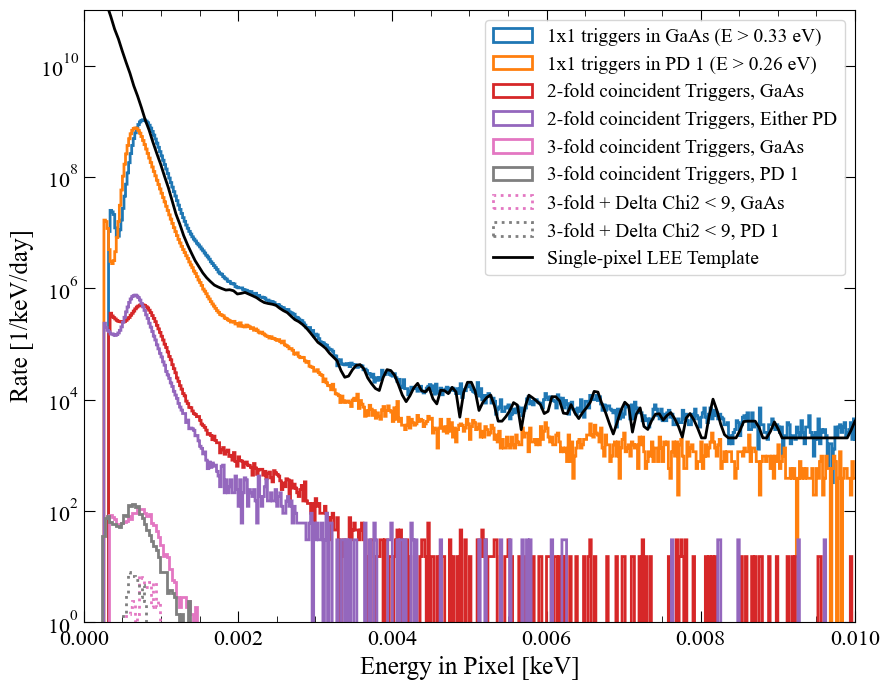

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(9, 7))
keV_bins = np.arange(0.1, 100, 0.02) * 1e-3


####################
# 1-fold coincidence
####################

single_pixel = E0_full > E_th_GaAs
duration_days = eff_exposure_GaAs_hours / 24
ax.hist(E0_full[single_pixel]*1e-3, bins=keV_bins,
        weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C0', lw=2,
        label=f'1x1 triggers in GaAs (E > {E_th_GaAs:.2f} eV)')
hist_E_E0_single, bin_edges = np.histogram(E0_full[single_pixel]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days))
R_single_GaAs = sum(hist_E_E0_single * np.diff(bin_edges))
print(f'Effective 1-fold exposure in GaAs: {duration_days:.2f} days')

single_pixel = E1_full > E_th_PD
duration_days = eff_exposure_PD1_hours / 24
ax.hist(E1_full[single_pixel]*1e-3, bins=keV_bins,
        weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C1', lw=2,
        label=f'1x1 triggers in PD 1 (E > {E_th_PD:.2f} eV)')
hist_E_E1_single, bin_edges = np.histogram(E1_full[single_pixel]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days))
R_single_PD_A = sum(hist_E_E1_single * np.diff(bin_edges))
print(f'Effective 1-fold exposure in PD 1: {duration_days:.2f} days')

# ####################
# # 2-fold coincidence
# ####################

detected = (E0_full > E_th_GaAs) * (E1_full > E_th_PD) + (E0_full > E_th_GaAs) * (E2_full > E_th_PD)
detected_A = (E0_full > E_th_GaAs) * (E1_full > E_th_PD)
detected_2fold = np.copy(detected)

duration_days = eff_exposure_per_run_GaAs_hours * eff_exposure_per_run_PD1_hours / run_length_hours / 24 * n_runs
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C3', lw=2,
        label='2-fold coincident Triggers, GaAs')
ax.hist(E1_full[detected_A]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected_A), 2/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C4', lw=2,
        label='2-fold coincident Triggers, Either PD')

hist_E_2fold_PD, bin_edges = np.histogram(E1_full[detected_A]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected_A), 2/np.diff(keV_bins)[0]/duration_days))
hist_E_2fold_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_2fold = sum(hist_E_2fold_GaAs * np.diff(bin_edges))

print(f'Effective 2-fold exposure: {duration_days:.2f} days')

# Export to a file
E_save = 0.5 * (keV_bins[1:] + keV_bins[:-1])
np.savetxt(dirname + 'background_spectrum_2fold.txt',
           np.column_stack((E_save, hist_E_2fold_GaAs)),
           header='Energy [keV]     dRdE GaAs [1/keV/day]',
           fmt='%.4e')


# ####################
# # 3-fold coincidence
# ####################

keV_bins = np.arange(0, 3, 0.03) * 1e-3  # Reduce the number of bins for 3-fold coincidence histogram
detected = (E0_full > E_th_GaAs) * (E1_full > E_th_PD) * (E2_full > E_th_PD)
duration_days = eff_exposure_per_run_GaAs_hours * eff_exposure_per_run_PD1_hours**2 / run_length_hours**2 / 24 * n_runs
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C6', lw=2,
        label='3-fold coincident Triggers, GaAs')
ax.hist(E1_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C7', lw=2,
        label='3-fold coincident Triggers, PD 1')

hist_E_3fold_PD, bin_edges = np.histogram(E1_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
hist_E_3fold_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_3fold = sum(hist_E_3fold_GaAs * np.diff(bin_edges))

print(f'Effective 3-fold exposure: {duration_days:.2f} days')

# ####################
# # Adding delta delta cut
# ####################

detected = (E0_full > E_th_GaAs) * (E1_full > E_th_PD) * (E2_full > E_th_PD) * (delta_delta_full < 9)
detected_overall = np.copy(detected)
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C6', lw=2, linestyle=':',
        label='3-fold + Delta Chi2 < 9, GaAs')
ax.hist(E1_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C7', lw=2, linestyle=':',
        label='3-fold + Delta Chi2 < 9, PD 1')

hist_E_3fold_delta_PD, bin_edges = np.histogram(E1_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
hist_E_3fold_delta_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_3fold_delta = sum(hist_E_3fold_delta_GaAs * np.diff(bin_edges))

# Export to a file
E_save = 0.5 * (keV_bins[1:] + keV_bins[:-1])
np.savetxt(dirname + 'background_spectrum_3fold.txt',
           np.column_stack((E_save, hist_E_3fold_delta_GaAs)),
           header='Energy [keV]     dRdE GaAs [1/keV/day]',
           fmt='%.4e')

# ####################
# # Wrapping up
# ####################


E_arr = np.linspace(0.1, 10, 200) * 1e-3
dRdE_arr = run57_lee_bkgd(scale_by=1/LEE_improvement_GaAs)(E_arr)
ax.plot(E_arr, dRdE_arr * 86400, color='k', label='Single-pixel LEE Template', lw=2)

ax.set_yscale('log')
ax.set_xlabel('Energy in Pixel [keV]')
ax.set_ylabel('Rate [1/keV/day]')
ax.set_ylim([1e0, 1e11])
ax.set_xlim([0, 10e-3])

ax.legend(loc='best', fontsize=14)
fig.tight_layout()
fig.show()

print(f'\nRates [1/day]:')
print(f'1-fold in GaAs: {R_single_GaAs:.0f}')
print(f'1-fold in PD 1: {R_single_PD_A:.0f}')
print(f'2-fold in GaAs, with either PD: {R_coincident_2fold:.2e}')
print(f'3-fold in GaAs: {R_coincident_3fold:.2e}')
print(f'3-fold in GaAs with Delta Chi2 < 9: {R_coincident_3fold_delta:.2e}')

print('\nRaw Numbers:')
print(f'Number of detected events: {len(E0_full):,}')
print(f'Number of events passing the 2-fold cut: {sum(detected_2fold):,}')
print(f'Number of events passing all cuts: {sum(detected_overall):,}')



# ER Stretch

In [ ]:
### Load template
template = detprocess.Template(verbose=True)
template.load_hdf5('/home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5')

# Load shared 2x1 template to get the energy scale right, but we only use the left channel template shape and PSD
channel = 'Mv3025pcBigFinsLeft|Mv3025pcBigFinsRight'

templates_td, t_sec_template, metadata = template.get_template(channel, return_metadata=True, tag='shared')
templates_td = np.reshape(templates_td[0,0], (1,1,templates_td.shape[-1]))
_, _, f_frequencies = templates_td.shape
fs = metadata['sample_rate']
pretrig = metadata['nb_pretrigger_samples']

csd, freqs_csd, _ = template.get_csd(channel, fold=False, return_metadata=True, tag='default')
csd = np.reshape(csd[0,0], (1,1,csd.shape[-1]))


### Convert to multichannel format

# Rescale template so that the energy resolution per channel is some assumed value
base_energy_resolution = 0.3977  # eV; this is the resolution of the 1x1 shared template from Run 57
GaAs_energy_resolution = 0.082
PD_energy_resolution = 0.031
n_sigma = 4.0  # Number of sigma for the trigger

E_th_GaAs = n_sigma * GaAs_energy_resolution
E_th_PD = n_sigma * PD_energy_resolution

E_exposure_GaAs = 0.45 # The energy cutoff to calculate effective exposure. Can be the threshold or some other value.
E_exposure_PD = 0.8

template_OF = np.zeros((3, 3, f_frequencies))
template_OF[0, 0, :] = np.copy(templates_td)
template_OF[1, 1, :] = np.copy(templates_td) 
template_OF[2, 2, :] = np.copy(templates_td)

csd_OF = np.zeros((3, 3, f_frequencies))
csd_OF[0, 0, :] = np.copy(csd) * (GaAs_energy_resolution / base_energy_resolution)**2
csd_OF[1, 1, :] = np.copy(csd) * (PD_energy_resolution / base_energy_resolution)**2
csd_OF[2, 2, :] = np.copy(csd) * (PD_energy_resolution / base_energy_resolution)**2


INFO: Loading filter data from file /home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5


In [ ]:
### Load the simulation parameters
run_length_hours = 6
dirname = 'stretch_performance_ER_like/'

E_max_PD_keV = 100e-3
E_max_GaAs_keV = 100e-3

LEE_improvement_PD = 400. # Per-volume improvement factor for the PD
LEE_volume_scale_PD = 4.5 # Ratio of PD volume to Run 57 Si volume

LEE_improvement_GaAs = 400. # Per-volume improvement factor for the GaAs
LEE_volume_scale_GaAs = 27 # Ratio of GaAs volume to Run 57 Si volume

# We probably don't change these
sim_trace_length = 1_250_000 * 10
sim_trace_length_s = sim_trace_length / fs  # Convert to seconds
n_simulations_per_run = int(np.floor(run_length_hours * 3600 / sim_trace_length_s))
n_traces_per_sim = int(sim_trace_length / f_frequencies)

In [ ]:
### Load the simulation results

E0_full = []
E1_full = []
E2_full = []
sim_number_full = []
trigger_time_full = []
delta_delta_full = []
detected_full = []

n_runs = 0
for run_id in range(50):
    fns = glob.glob(dirname + f'my_simulation_3fold_{run_id:02d}*.pkl')
    if len(fns) == 0:
        continue
    with open(fns[0], 'rb') as f:
        results = pickle.load(f)
        
        E0_full += [e for result in results for e in result[0]]
        E1_full += [e for result in results for e in result[1]]
        E2_full += [e for result in results for e in result[2]]
        sim_number_full += [e for result in results for e in result[3]]
        trigger_time_full += [e for result in results for e in result[4]]
        delta_delta_full += [e for result in results for e in result[5]]
        detected_full += [e for result in results for e in result[6]]
        
        n_runs += 1
        del results
    print(run_id)

print(f'Loaded {n_runs} runs of simulation results.')

E0_full = np.array(E0_full)
E1_full = np.array(E1_full)
E2_full = np.array(E2_full)
sim_number_full = np.array(sim_number_full)
trigger_time_full = np.array(trigger_time_full)
delta_delta_full = np.array(delta_delta_full)
detected_full = np.array(detected_full)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
Loaded 47 runs of simulation results.


In [ ]:
### Calculate the effective exposure in the GaAs and PD detectors, based on the observed triggers

# Exposure in a single PD detector
n_triggers_obs_PD1 = sum(E1_full > E_exposure_PD)
print(f'\nNumber of triggers observed in PD 1: {n_triggers_obs_PD1}')

E_above_th_PD1 = np.geomspace(E_exposure_PD * 1e-3, E_max_PD_keV, 250)
dRdE_above_th_PD1 = run57_lee_bkgd(scale_by=1/LEE_improvement_PD)(E_above_th_PD1)
R_above_th_PD1 = np.trapz(dRdE_above_th_PD1, E_above_th_PD1)
print(f'Expected rate of triggers in PD 1 above threshold: {R_above_th_PD1:.2e} Hz')

eff_exposure_PD1_hours = n_triggers_obs_PD1 / R_above_th_PD1 / 3600
print(f'Effective exposure in PD: {eff_exposure_PD1_hours:.2f} hours (no volume scaling or LEE improvement)')

# Exposure in the GaAs detector
n_triggers_obs_GaAs = sum(E0_full > E_exposure_GaAs)
print(f'\nNumber of triggers observed in GaAs: {n_triggers_obs_GaAs}')

E_above_th_GaAs = np.geomspace(E_exposure_GaAs * 1e-3, E_max_GaAs_keV, 250)
dRdE_above_th_GaAs = run57_lee_bkgd(scale_by=1/LEE_improvement_GaAs)(E_above_th_GaAs)
R_above_th_GaAs = np.trapz(dRdE_above_th_GaAs, E_above_th_GaAs)
print(f'Expected rate of triggers in GaAs above threshold: {R_above_th_GaAs:.2e} Hz')

eff_exposure_GaAs_hours = n_triggers_obs_GaAs / R_above_th_GaAs / 3600
print(f'Effective exposure in GaAs: {eff_exposure_GaAs_hours / 24:.2f} days (no volume scaling or LEE improvement)')

# Apply the LEE and volume scaling
print('\n##########################\n')
eff_exposure_PD1_hours /= LEE_volume_scale_PD
eff_exposure_per_run_PD1_hours = eff_exposure_PD1_hours / n_runs
eff_exposure_GaAs_hours /= LEE_volume_scale_GaAs
eff_exposure_per_run_GaAs_hours = eff_exposure_GaAs_hours / n_runs
print(f'Effective exposure in PD after LEE and volume scaling: {eff_exposure_PD1_hours:.2f} hours ({eff_exposure_per_run_PD1_hours:.2f} hours per run)')
print(f'Effective exposure in GaAs after LEE and volume scaling: {eff_exposure_GaAs_hours:.2f} hours ({eff_exposure_per_run_GaAs_hours:.2f} hours per run)')


Number of triggers observed in PD 1: 23880206
Expected rate of triggers in PD 1 above threshold: 3.32e+00 Hz
Effective exposure in PD: 2000.38 hours (no volume scaling or LEE improvement)

Number of triggers observed in GaAs: 24395043
Expected rate of triggers in GaAs above threshold: 1.29e+00 Hz
Effective exposure in GaAs: 218.52 days (no volume scaling or LEE improvement)

##########################

Effective exposure in PD after LEE and volume scaling: 6251.18 hours (127.58 hours per run)
Effective exposure in GaAs after LEE and volume scaling: 3746.13 hours (76.45 hours per run)


Effective 1-fold exposure in GaAs: 156.09 days
Effective 1-fold exposure in PD 1: 260.47 days
Effective 2-fold exposure: 3183.37 days
Effective 3-fold exposure: 67686.44 days

Rates [1/day]:
1-fold in GaAs: 264776
1-fold in PD 1: 180972
2-fold in GaAs, with either PD: 1.38e+02
3-fold in GaAs: 4.90e-02
3-fold in GaAs with Delta Chi2 < 9: 8.42e-04

Raw Numbers:
Number of detected events: 140,284,822
Number of events passing the 2-fold cut: 439,694
Number of events passing all cuts: 57


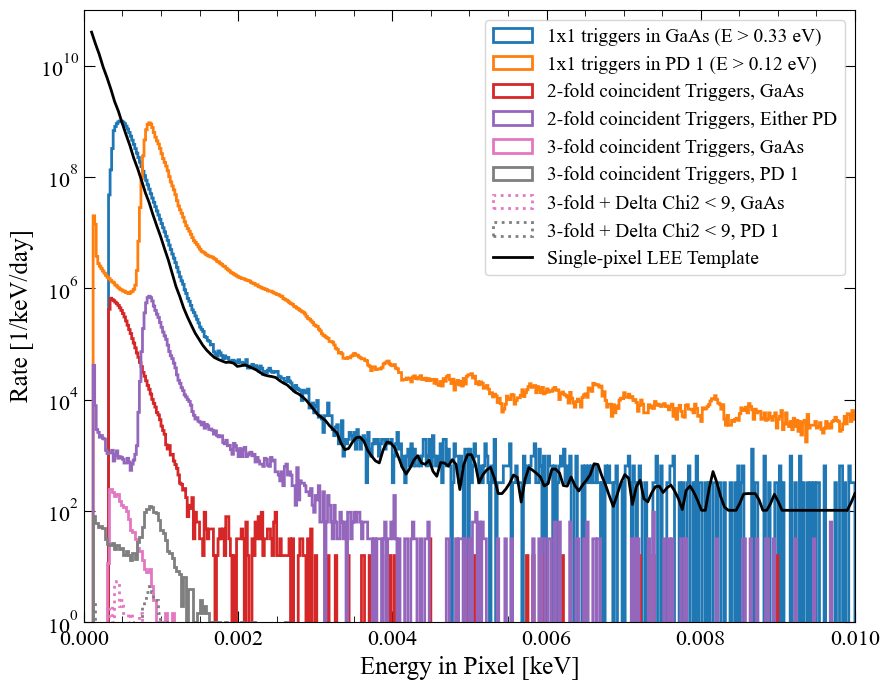

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(9, 7))
keV_bins = np.arange(0.1, 100, 0.02) * 1e-3


####################
# 1-fold coincidence
####################

single_pixel = E0_full > E_th_GaAs
duration_days = eff_exposure_GaAs_hours / 24
ax.hist(E0_full[single_pixel]*1e-3, bins=keV_bins,
        weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C0', lw=2,
        label=f'1x1 triggers in GaAs (E > {E_th_GaAs:.2f} eV)')
hist_E_E0_single, bin_edges = np.histogram(E0_full[single_pixel]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days))
R_single_GaAs = sum(hist_E_E0_single * np.diff(bin_edges))
print(f'Effective 1-fold exposure in GaAs: {duration_days:.2f} days')

single_pixel = E1_full > E_th_PD
duration_days = eff_exposure_PD1_hours / 24
ax.hist(E1_full[single_pixel]*1e-3, bins=keV_bins,
        weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C1', lw=2,
        label=f'1x1 triggers in PD 1 (E > {E_th_PD:.2f} eV)')
hist_E_E1_single, bin_edges = np.histogram(E1_full[single_pixel]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days))
R_single_PD_A = sum(hist_E_E1_single * np.diff(bin_edges))
print(f'Effective 1-fold exposure in PD 1: {duration_days:.2f} days')

# ####################
# # 2-fold coincidence
# ####################

detected = (E0_full > E_th_GaAs) * (E1_full > E_th_PD) + (E0_full > E_th_GaAs) * (E2_full > E_th_PD)
detected_A = (E0_full > E_th_GaAs) * (E1_full > E_th_PD)
detected_2fold = np.copy(detected)

duration_days = eff_exposure_per_run_GaAs_hours * eff_exposure_per_run_PD1_hours / run_length_hours / 24 * n_runs
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C3', lw=2,
        label='2-fold coincident Triggers, GaAs')
ax.hist(E1_full[detected_A]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected_A), 2/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C4', lw=2,
        label='2-fold coincident Triggers, Either PD')

hist_E_2fold_PD, bin_edges = np.histogram(E1_full[detected_A]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected_A), 2/np.diff(keV_bins)[0]/duration_days))
hist_E_2fold_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_2fold = sum(hist_E_2fold_GaAs * np.diff(bin_edges))

print(f'Effective 2-fold exposure: {duration_days:.2f} days')

# Export to a file
E_save = 0.5 * (keV_bins[1:] + keV_bins[:-1])
np.savetxt(dirname + 'background_spectrum_2fold.txt',
           np.column_stack((E_save, hist_E_2fold_GaAs)),
           header='Energy [keV]     dRdE GaAs [1/keV/day]',
           fmt='%.4e')


# ####################
# # 3-fold coincidence
# ####################

keV_bins = np.arange(0, 3, 0.03) * 1e-3  # Reduce the number of bins for 3-fold coincidence histogram
detected = (E0_full > E_th_GaAs) * (E1_full > E_th_PD) * (E2_full > E_th_PD)
duration_days = eff_exposure_per_run_GaAs_hours * eff_exposure_per_run_PD1_hours**2 / run_length_hours**2 / 24 * n_runs
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C6', lw=2,
        label='3-fold coincident Triggers, GaAs')
ax.hist(E1_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C7', lw=2,
        label='3-fold coincident Triggers, PD 1')

hist_E_3fold_PD, bin_edges = np.histogram(E1_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
hist_E_3fold_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_3fold = sum(hist_E_3fold_GaAs * np.diff(bin_edges))

print(f'Effective 3-fold exposure: {duration_days:.2f} days')

# ####################
# # Adding delta delta cut
# ####################

detected = (E0_full > E_th_GaAs) * (E1_full > E_th_PD) * (E2_full > E_th_PD) * (delta_delta_full < 9)
detected_overall = np.copy(detected)
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C6', lw=2, linestyle=':',
        label='3-fold + Delta Chi2 < 9, GaAs')
ax.hist(E1_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C7', lw=2, linestyle=':',
        label='3-fold + Delta Chi2 < 9, PD 1')

hist_E_3fold_delta_PD, bin_edges = np.histogram(E1_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
hist_E_3fold_delta_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_3fold_delta = sum(hist_E_3fold_delta_GaAs * np.diff(bin_edges))

# Export to a file
E_save = 0.5 * (keV_bins[1:] + keV_bins[:-1])
np.savetxt(dirname + 'background_spectrum_3fold.txt',
           np.column_stack((E_save, hist_E_3fold_delta_GaAs)),
           header='Energy [keV]     dRdE GaAs [1/keV/day]',
           fmt='%.4e')

# ####################
# # Wrapping up
# ####################


E_arr = np.linspace(0.1, 10, 200) * 1e-3
dRdE_arr = run57_lee_bkgd(scale_by=1/LEE_improvement_GaAs)(E_arr)
ax.plot(E_arr, dRdE_arr * 86400, color='k', label='Single-pixel LEE Template', lw=2)

ax.set_yscale('log')
ax.set_xlabel('Energy in Pixel [keV]')
ax.set_ylabel('Rate [1/keV/day]')
ax.set_ylim([1e0, 1e11])
ax.set_xlim([0, 10e-3])

ax.legend(loc='best', fontsize=14)
fig.tight_layout()
fig.show()

print(f'\nRates [1/day]:')
print(f'1-fold in GaAs: {R_single_GaAs:.0f}')
print(f'1-fold in PD 1: {R_single_PD_A:.0f}')
print(f'2-fold in GaAs, with either PD: {R_coincident_2fold:.2e}')
print(f'3-fold in GaAs: {R_coincident_3fold:.2e}')
print(f'3-fold in GaAs with Delta Chi2 < 9: {R_coincident_3fold_delta:.2e}')

print('\nRaw Numbers:')
print(f'Number of detected events: {len(E0_full):,}')
print(f'Number of events passing the 2-fold cut: {sum(detected_2fold):,}')
print(f'Number of events passing all cuts: {sum(detected_overall):,}')



# Testing

In [3]:
### Load template
template = detprocess.Template(verbose=True)
template.load_hdf5('/home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5')

# Load shared 2x1 template to get the energy scale right, but we only use the left channel template shape and PSD
channel = 'Mv3025pcBigFinsLeft|Mv3025pcBigFinsRight'

templates_td, t_sec_template, metadata = template.get_template(channel, return_metadata=True, tag='shared')
templates_td = np.reshape(templates_td[0,0], (1,1,templates_td.shape[-1]))
_, _, f_frequencies = templates_td.shape
fs = metadata['sample_rate']
pretrig = metadata['nb_pretrigger_samples']

csd, freqs_csd, _ = template.get_csd(channel, fold=False, return_metadata=True, tag='default')
csd = np.reshape(csd[0,0], (1,1,csd.shape[-1]))


### Convert to multichannel format

# Rescale template so that the energy resolution per channel is some assumed value
base_energy_resolution = 0.3977  # eV; this is the resolution of the 1x1 shared template from Run 57
GaAs_energy_resolution = 0.944
PD_energy_resolution = 0.190

E_th_PD = 1.
E_th_GaAs = 15.

E_exposure_GaAs = E_th_GaAs # The energy cutoff to calculate effective exposure. Can be the threshold or some other value.
E_exposure_PD = E_th_PD

template_OF = np.zeros((3, 3, f_frequencies))
template_OF[0, 0, :] = np.copy(templates_td)
template_OF[1, 1, :] = np.copy(templates_td) 
template_OF[2, 2, :] = np.copy(templates_td)

csd_OF = np.zeros((3, 3, f_frequencies))
csd_OF[0, 0, :] = np.copy(csd) * (GaAs_energy_resolution / base_energy_resolution)**2
csd_OF[1, 1, :] = np.copy(csd) * (PD_energy_resolution / base_energy_resolution)**2
csd_OF[2, 2, :] = np.copy(csd) * (PD_energy_resolution / base_energy_resolution)**2


INFO: Loading filter data from file /home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5


In [4]:
### Load the simulation parameters
run_length_hours = 3
dirname = 'GatewayReview/gaas_NR_requirement/'

E_max_PD_keV = 30e-3
E_max_GaAs_keV = 300e-3

LEE_improvement_PD = 1. # Per-volume improvement factor for the PD
LEE_volume_scale_PD = 225 * 0.3 / 100 # Ratio of PD volume to Run 57 Si volume

LEE_improvement_GaAs = 1. # Per-volume improvement factor for the GaAs
LEE_volume_scale_GaAs = 225 * 4 / 100 # Ratio of GaAs volume to Run 57 Si volume

# We probably don't change these
sim_trace_length = 1_250_000 * 10
sim_trace_length_s = sim_trace_length / fs  # Convert to seconds
n_simulations_per_run = int(np.floor(run_length_hours * 3600 / sim_trace_length_s))
n_traces_per_sim = int(sim_trace_length / f_frequencies)

In [5]:
### Load the simulation results

E0_full = []
E1_full = []
E2_full = []
sim_number_full = []
trigger_time_full = []
delta_delta_full = []
detected_full = []

n_runs = 0
for run_id in range(50):
    fns = glob.glob(dirname + f'my_simulation_2fold_{run_id:02d}*.pkl')
    if len(fns) == 0:
        continue
    with open(fns[0], 'rb') as f:
        results = pickle.load(f)
        
        E0_full += [e for result in results for e in result[0]]
        E1_full += [e for result in results for e in result[1]]
        E2_full += [e for result in results for e in result[2]]
        sim_number_full += [e for result in results for e in result[3]]
        trigger_time_full += [e for result in results for e in result[4]]
        delta_delta_full += [e for result in results for e in result[5]]
        detected_full += [e for result in results for e in result[6]]
        
        n_runs += 1
        del results
    print(run_id)

print(f'Loaded {n_runs} runs of simulation results.')

E0_full = np.array(E0_full)
E1_full = np.array(E1_full)
E2_full = np.array(E2_full)
sim_number_full = np.array(sim_number_full)
trigger_time_full = np.array(trigger_time_full)
delta_delta_full = np.array(delta_delta_full)
detected_full = np.array(detected_full)


0
1
3
4
6
7
9
10
12
13
15
16
18
19
Loaded 14 runs of simulation results.


In [6]:
### Calculate the effective exposure in the GaAs and PD detectors, based on the observed triggers

# Exposure in a single PD detector
n_triggers_obs_PD1 = sum(E1_full > E_exposure_PD)
print(f'\nNumber of triggers observed in PD 1: {n_triggers_obs_PD1}')

E_above_th_PD1 = np.geomspace(E_exposure_PD * 1e-3, E_max_PD_keV, 250)
dRdE_above_th_PD1 = run57_lee_bkgd(scale_by=1/LEE_improvement_PD)(E_above_th_PD1)
R_above_th_PD1 = np.trapz(dRdE_above_th_PD1, E_above_th_PD1)
print(f'Expected rate of triggers in PD 1 above threshold: {R_above_th_PD1:.2e} Hz')

eff_exposure_PD1_hours = n_triggers_obs_PD1 / R_above_th_PD1 / 3600
print(f'Effective exposure in PD: {eff_exposure_PD1_hours:.2f} hours (no volume scaling or LEE improvement)')

# Exposure in the GaAs detector
n_triggers_obs_GaAs = sum(E0_full > E_exposure_GaAs)
print(f'\nNumber of triggers observed in GaAs: {n_triggers_obs_GaAs}')

E_above_th_GaAs = np.geomspace(E_exposure_GaAs * 1e-3, E_max_GaAs_keV, 250)
dRdE_above_th_GaAs = run57_lee_bkgd(scale_by=1/LEE_improvement_GaAs)(E_above_th_GaAs)
R_above_th_GaAs = np.trapz(dRdE_above_th_GaAs, E_above_th_GaAs)
print(f'Expected rate of triggers in GaAs above threshold: {R_above_th_GaAs:.2e} Hz')

eff_exposure_GaAs_hours = n_triggers_obs_GaAs / R_above_th_GaAs / 3600
print(f'Effective exposure in GaAs: {eff_exposure_GaAs_hours / 24:.2f} days (no volume scaling or LEE improvement)')

# Apply the LEE and volume scaling
print('\n##########################\n')
eff_exposure_PD1_hours /= LEE_volume_scale_PD
eff_exposure_per_run_PD1_hours = eff_exposure_PD1_hours / n_runs
eff_exposure_GaAs_hours /= LEE_volume_scale_GaAs
eff_exposure_per_run_GaAs_hours = eff_exposure_GaAs_hours / n_runs
print(f'Effective exposure in PD after LEE and volume scaling: {eff_exposure_PD1_hours:.2f} hours ({eff_exposure_per_run_PD1_hours:.2f} hours per run)')
print(f'Effective exposure in GaAs after LEE and volume scaling: {eff_exposure_GaAs_hours:.2f} hours ({eff_exposure_per_run_GaAs_hours:.2f} hours per run)')


Number of triggers observed in PD 1: 3008519
Expected rate of triggers in PD 1 above threshold: 4.40e+00 Hz
Effective exposure in PD: 189.90 hours (no volume scaling or LEE improvement)

Number of triggers observed in GaAs: 1633899
Expected rate of triggers in GaAs above threshold: 3.00e-03 Hz
Effective exposure in GaAs: 6307.88 days (no volume scaling or LEE improvement)

##########################

Effective exposure in PD after LEE and volume scaling: 281.33 hours (20.10 hours per run)
Effective exposure in GaAs after LEE and volume scaling: 16821.00 hours (1201.50 hours per run)


Effective 2-fold PD exposure: 78.52 days

Rates [1/day]:
2-fold in GaAs, with either PD: 0.00e+00


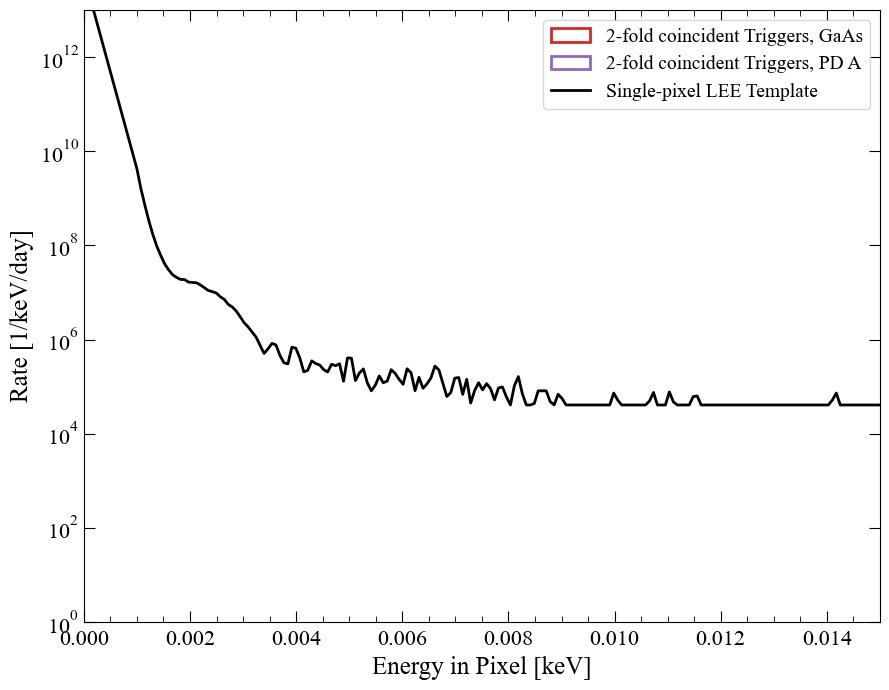

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(9, 7))
keV_bins = np.arange(0.1, 100, 0.02) * 1e-3


# ####################
# # 2-fold PD coincidence
# ####################

detected = (E1_full > E_th_PD) * (E2_full > E_th_PD) 

duration_days = eff_exposure_per_run_PD1_hours * eff_exposure_per_run_PD1_hours / run_length_hours / 24 * n_runs
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C3', lw=2,
        label='2-fold coincident Triggers, GaAs')
ax.hist(E1_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C4', lw=2,
        label='2-fold coincident Triggers, PD A')

hist_E_2fold_PD, bin_edges = np.histogram(E1_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
hist_E_2fold_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_2fold = sum(hist_E_2fold_GaAs * np.diff(bin_edges))

print(f'Effective 2-fold PD exposure: {duration_days:.2f} days')

# ####################
# # Wrapping up
# ####################


E_arr = np.linspace(0.1, 15, 200) * 1e-3
dRdE_arr = run57_lee_bkgd(scale_by=1/LEE_improvement_GaAs)(E_arr)
ax.plot(E_arr, dRdE_arr * 86400, color='k', label='Single-pixel LEE Template', lw=2)

ax.set_yscale('log')
ax.set_xlabel('Energy in Pixel [keV]')
ax.set_ylabel('Rate [1/keV/day]')
ax.set_ylim([1e0, 1e13])
ax.set_xlim([0, 15e-3])

ax.legend(loc='upper right', fontsize=14)
fig.tight_layout()
fig.show()

print(f'\nRates [1/day]:')
print(f'2-fold in GaAs, with either PD: {R_coincident_2fold:.2e}')


Effective 1-fold exposure in GaAs: 700.88 days
Effective 1-fold exposure in PD 1: 11.72 days
Effective 2-fold PD exposure: 4694.74 days

Rates [1/day]:
2-fold in GaAs, with either PD: 3.56e-02
Number of coincident events: 167


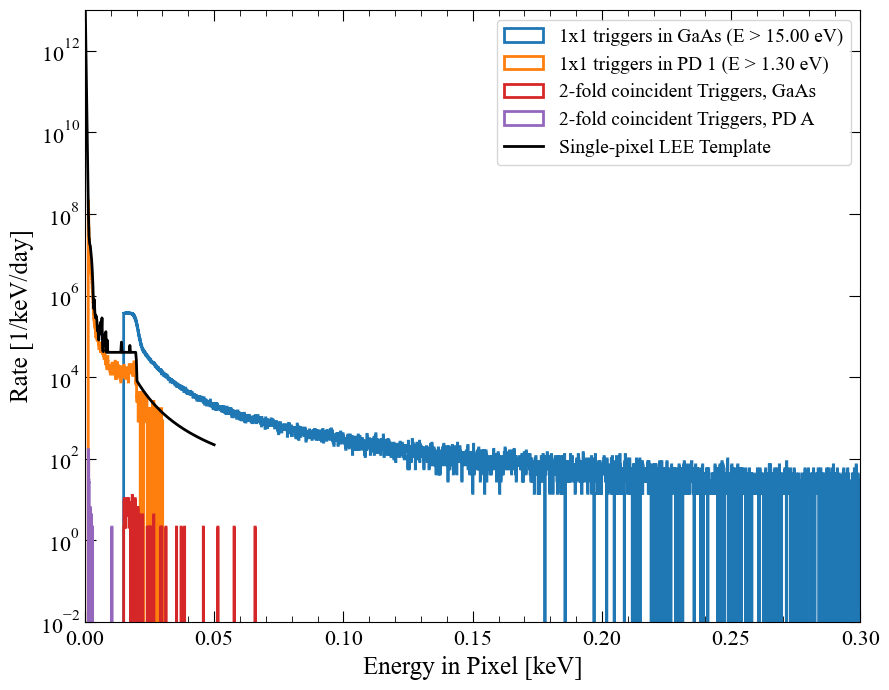

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(9, 7))
keV_bins = np.arange(0, 300, 0.1) * 1e-3 

E_th_PD = 1.3

####################
# 1-fold coincidence
####################

single_pixel = E0_full > E_th_GaAs
duration_days = eff_exposure_GaAs_hours / 24
ax.hist(E0_full[single_pixel]*1e-3, bins=keV_bins,
        weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C0', lw=2,
        label=f'1x1 triggers in GaAs (E > {E_th_GaAs:.2f} eV)')
hist_E_E0_single, bin_edges = np.histogram(E0_full[single_pixel]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days))
R_single_GaAs = sum(hist_E_E0_single * np.diff(bin_edges))
print(f'Effective 1-fold exposure in GaAs: {duration_days:.2f} days')

single_pixel = E1_full > E_th_PD
duration_days = eff_exposure_PD1_hours / 24
ax.hist(E1_full[single_pixel]*1e-3, bins=keV_bins,
        weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C1', lw=2,
        label=f'1x1 triggers in PD 1 (E > {E_th_PD:.2f} eV)')
hist_E_E1_single, bin_edges = np.histogram(E1_full[single_pixel]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days))
R_single_PD_A = sum(hist_E_E1_single * np.diff(bin_edges))
print(f'Effective 1-fold exposure in PD 1: {duration_days:.2f} days')

####################
# 2-fold coincidence
####################

detected = (E0_full > E_th_GaAs) * (E1_full > E_th_PD) * (delta_delta_full < 9)
detected_overall = np.copy(detected)
duration_days = eff_exposure_per_run_PD1_hours * eff_exposure_per_run_GaAs_hours / run_length_hours / 24 * n_runs
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C3', lw=2,
        label='2-fold coincident Triggers, GaAs')
ax.hist(E1_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C4', lw=2,
        label='2-fold coincident Triggers, PD A')

hist_E_2fold_PD, bin_edges = np.histogram(E1_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
hist_E_2fold_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_2fold = sum(hist_E_2fold_GaAs * np.diff(bin_edges))

print(f'Effective 2-fold PD exposure: {duration_days:.2f} days')

# Export to a file
E_save = 0.5 * (keV_bins[1:] + keV_bins[:-1])
np.savetxt(dirname + f'LEE_2fold_PD_{E_th_PD:.1f}_GaAs_{E_th_GaAs:.1f}.txt',
           np.column_stack((E_save, hist_E_2fold_GaAs)),
           header='Energy [keV]     dRdE GaAs [1/keV/day]',
           fmt='%.4e')

# ####################
# # Wrapping up
# ####################


E_arr = np.linspace(0.1, 50, 200) * 1e-3
dRdE_arr = run57_lee_bkgd(scale_by=1/LEE_improvement_GaAs)(E_arr)
ax.plot(E_arr, dRdE_arr * 86400, color='k', label='Single-pixel LEE Template', lw=2)

ax.set_yscale('log')
ax.set_xlabel('Energy in Pixel [keV]')
ax.set_ylabel('Rate [1/keV/day]')
ax.set_ylim([1e-2, 1e13])
ax.set_xlim([0, 300e-3])

ax.legend(loc='upper right', fontsize=14)
fig.tight_layout()
fig.show()

print(f'\nRates [1/day]:')
print(f'2-fold in GaAs, with either PD: {R_coincident_2fold:.2e}')
print(f'Number of coincident events: {sum(detected):,}')

Effective 1-fold exposure in GaAs: 71.00 days
Effective 1-fold exposure in PD 1: 0.07 days
Effective 2-fold exposure: 112.92 days
Effective 3-fold exposure: 179.59 days

Rates [1/day]:
1-fold in GaAs: 1086
1-fold in PD 1: 113943
2-fold in GaAs, with either PD: 6.91e-01
3-fold in GaAs: 0.00e+00
3-fold in GaAs with Delta Chi2 < 9: 0.00e+00

Raw Numbers:
Number of detected events: 183,499
Number of events passing the 2-fold cut: 78
Number of events passing all cuts: 0


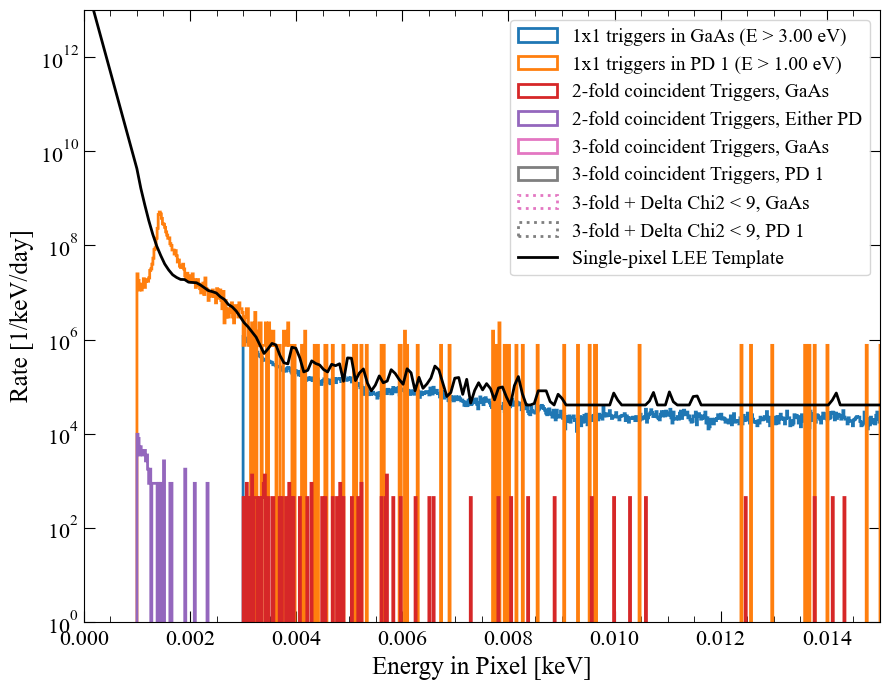

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(9, 7))
keV_bins = np.arange(0.1, 100, 0.02) * 1e-3

####################
# 1-fold coincidence
####################

single_pixel = E0_full > E_th_GaAs
duration_days = eff_exposure_GaAs_hours / 24
ax.hist(E0_full[single_pixel]*1e-3, bins=keV_bins,
        weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C0', lw=2,
        label=f'1x1 triggers in GaAs (E > {E_th_GaAs:.2f} eV)')
hist_E_E0_single, bin_edges = np.histogram(E0_full[single_pixel]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days))
R_single_GaAs = sum(hist_E_E0_single * np.diff(bin_edges))
print(f'Effective 1-fold exposure in GaAs: {duration_days:.2f} days')

single_pixel = E1_full > E_th_PD
duration_days = eff_exposure_PD1_hours / 24
ax.hist(E1_full[single_pixel]*1e-3, bins=keV_bins,
        weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C1', lw=2,
        label=f'1x1 triggers in PD 1 (E > {E_th_PD:.2f} eV)')
hist_E_E1_single, bin_edges = np.histogram(E1_full[single_pixel]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days))
R_single_PD_A = sum(hist_E_E1_single * np.diff(bin_edges))
print(f'Effective 1-fold exposure in PD 1: {duration_days:.2f} days')

# ####################
# # 2-fold coincidence
# ####################

detected = (E0_full > E_th_GaAs) * (E1_full > E_th_PD) + (E0_full > E_th_GaAs) * (E2_full > E_th_PD)
detected_A = (E0_full > E_th_GaAs) * (E1_full > E_th_PD)
detected_2fold = np.copy(detected)

duration_days = eff_exposure_per_run_GaAs_hours * eff_exposure_per_run_PD1_hours / run_length_hours / 24 * n_runs
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C3', lw=2,
        label='2-fold coincident Triggers, GaAs')
ax.hist(E1_full[detected_A]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected_A), 2/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C4', lw=2,
        label='2-fold coincident Triggers, Either PD')

hist_E_2fold_PD, bin_edges = np.histogram(E1_full[detected_A]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected_A), 2/np.diff(keV_bins)[0]/duration_days))
hist_E_2fold_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_2fold = sum(hist_E_2fold_GaAs * np.diff(bin_edges))

print(f'Effective 2-fold exposure: {duration_days:.2f} days')

# Export to a file
E_save = 0.5 * (keV_bins[1:] + keV_bins[:-1])
np.savetxt(dirname + 'background_spectrum_2fold.txt',
           np.column_stack((E_save, hist_E_2fold_GaAs)),
           header='Energy [keV]     dRdE GaAs [1/keV/day]',
           fmt='%.4e')


# ####################
# # 3-fold coincidence
# ####################

keV_bins = np.arange(0, 20, 0.03) * 1e-3  # Reduce the number of bins for 3-fold coincidence histogram
detected = (E0_full > E_th_GaAs) * (E1_full > E_th_PD) * (E2_full > E_th_PD)
duration_days = eff_exposure_per_run_GaAs_hours * eff_exposure_per_run_PD1_hours**2 / run_length_hours**2 / 24 * n_runs
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C6', lw=2,
        label='3-fold coincident Triggers, GaAs')
ax.hist(E1_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C7', lw=2,
        label='3-fold coincident Triggers, PD 1')

hist_E_3fold_PD, bin_edges = np.histogram(E1_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
hist_E_3fold_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_3fold = sum(hist_E_3fold_GaAs * np.diff(bin_edges))

print(f'Effective 3-fold exposure: {duration_days:.2f} days')

# ####################
# # Adding delta delta cut
# ####################

detected = (E0_full > E_th_GaAs) * (E1_full > E_th_PD) * (E2_full > E_th_PD) * (delta_delta_full < 9)
detected_overall = np.copy(detected)
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C6', lw=2, linestyle=':',
        label='3-fold + Delta Chi2 < 9, GaAs')
ax.hist(E1_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C7', lw=2, linestyle=':',
        label='3-fold + Delta Chi2 < 9, PD 1')

hist_E_3fold_delta_PD, bin_edges = np.histogram(E1_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
hist_E_3fold_delta_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_3fold_delta = sum(hist_E_3fold_delta_GaAs * np.diff(bin_edges))

# Export to a file
E_save = 0.5 * (keV_bins[1:] + keV_bins[:-1])
np.savetxt(dirname + 'background_spectrum_3fold.txt',
           np.column_stack((E_save, hist_E_3fold_delta_GaAs)),
           header='Energy [keV]     dRdE GaAs [1/keV/day]',
           fmt='%.4e')

# ####################
# # Wrapping up
# ####################


E_arr = np.linspace(0.1, 15, 200) * 1e-3
dRdE_arr = run57_lee_bkgd(scale_by=1/LEE_improvement_GaAs)(E_arr)
ax.plot(E_arr, dRdE_arr * 86400, color='k', label='Single-pixel LEE Template', lw=2)

ax.set_yscale('log')
ax.set_xlabel('Energy in Pixel [keV]')
ax.set_ylabel('Rate [1/keV/day]')
ax.set_ylim([1e0, 1e13])
ax.set_xlim([0, 15e-3])

ax.legend(loc='upper right', fontsize=14)
fig.tight_layout()
fig.show()

print(f'\nRates [1/day]:')
print(f'1-fold in GaAs: {R_single_GaAs:.0f}')
print(f'1-fold in PD 1: {R_single_PD_A:.0f}')
print(f'2-fold in GaAs, with either PD: {R_coincident_2fold:.2e}')
print(f'3-fold in GaAs: {R_coincident_3fold:.2e}')
print(f'3-fold in GaAs with Delta Chi2 < 9: {R_coincident_3fold_delta:.2e}')

print('\nRaw Numbers:')
print(f'Number of detected events: {len(E0_full):,}')
print(f'Number of events passing the 2-fold cut: {sum(detected_2fold):,}')
print(f'Number of events passing all cuts: {sum(detected_overall):,}')



In [11]:

for E_th_PD in [1.0, 1.1, 1.2, 1.3]:
        for E_th_GaAs in [1.0, 1.5, 2.0, 2.5]:

                ######################
                # 3-fold coincidence
                ######################
                
                keV_bins = np.arange(0, 20, 0.03) * 1e-3  # Reduce the number of bins for 3-fold coincidence histogram
                duration_days = eff_exposure_per_run_GaAs_hours * eff_exposure_per_run_PD1_hours**2 / run_length_hours**2 / 24 * n_runs

                detected = (E0_full > E_th_GaAs) * (E1_full > E_th_PD) * (E2_full > E_th_PD) * (delta_delta_full < 9)
                detected_overall = np.copy(detected)

                hist_E_3fold_delta_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                                weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
                R_coincident_3fold_delta = sum(hist_E_3fold_delta_GaAs * np.diff(bin_edges))

                # Export to a file
                E_save = 0.5 * (keV_bins[1:] + keV_bins[:-1])
                np.savetxt(dirname + f'background_spectrum_3fold_PD_{E_th_PD:.1f}eV_GaAs_{E_th_GaAs:.1f}eV.txt',
                        np.column_stack((E_save, hist_E_3fold_delta_GaAs)),
                        header='Energy [keV]     dRdE GaAs [1/keV/day]',
                        fmt='%.4e')

                print(f'E_th_PD = {E_th_PD}, E_th_GaAs = {E_th_GaAs}: 3-fold in GaAs with Delta Chi2 < 9: {R_coincident_3fold_delta:.2e}')

print('')
for E_th_PD in [1.0, 1.1, 1.2, 1.3]:
        for E_th_GaAs in [1.0, 1.5, 2.0, 2.5]:
        
                ####################
                # 2-fold coincidence
                ####################

                detected = (E0_full > E_th_GaAs) * (E1_full > E_th_PD) + (E0_full > E_th_GaAs) * (E2_full > E_th_PD)
                duration_days = eff_exposure_per_run_GaAs_hours * eff_exposure_per_run_PD1_hours / run_length_hours / 24 * n_runs
                hist_E_2fold_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                                weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
                R_coincident_2fold = sum(hist_E_2fold_GaAs * np.diff(bin_edges))

                # Export to a file
                E_save = 0.5 * (keV_bins[1:] + keV_bins[:-1])
                np.savetxt(dirname + f'background_spectrum_2fold_PD_{E_th_PD:.1f}eV_GaAs_{E_th_GaAs:.1f}eV.txt',
                        np.column_stack((E_save, hist_E_2fold_GaAs)),
                        header='Energy [keV]     dRdE GaAs [1/keV/day]',
                        fmt='%.4e')

                print(f'E_th_PD = {E_th_PD}, E_th_GaAs = {E_th_GaAs}: 2-fold in GaAs with Delta Chi2 < 9: {R_coincident_2fold:.2e}')


E_th_PD = 1.0, E_th_GaAs = 1.0: 3-fold in GaAs with Delta Chi2 < 9: 2.01e-01
E_th_PD = 1.0, E_th_GaAs = 1.5: 3-fold in GaAs with Delta Chi2 < 9: 8.94e-02
E_th_PD = 1.0, E_th_GaAs = 2.0: 3-fold in GaAs with Delta Chi2 < 9: 2.73e-02
E_th_PD = 1.0, E_th_GaAs = 2.5: 3-fold in GaAs with Delta Chi2 < 9: 5.46e-03
E_th_PD = 1.1, E_th_GaAs = 1.0: 3-fold in GaAs with Delta Chi2 < 9: 5.61e-02
E_th_PD = 1.1, E_th_GaAs = 1.5: 3-fold in GaAs with Delta Chi2 < 9: 2.58e-02
E_th_PD = 1.1, E_th_GaAs = 2.0: 3-fold in GaAs with Delta Chi2 < 9: 8.94e-03
E_th_PD = 1.1, E_th_GaAs = 2.5: 3-fold in GaAs with Delta Chi2 < 9: 1.99e-03
E_th_PD = 1.2, E_th_GaAs = 1.0: 3-fold in GaAs with Delta Chi2 < 9: 1.89e-02
E_th_PD = 1.2, E_th_GaAs = 1.5: 3-fold in GaAs with Delta Chi2 < 9: 8.94e-03
E_th_PD = 1.2, E_th_GaAs = 2.0: 3-fold in GaAs with Delta Chi2 < 9: 3.48e-03
E_th_PD = 1.2, E_th_GaAs = 2.5: 3-fold in GaAs with Delta Chi2 < 9: 4.97e-04
E_th_PD = 1.3, E_th_GaAs = 1.0: 3-fold in GaAs with Delta Chi2 < 9: 4.97e-03